# Example 01 - Build Geospatial PRMS Domain

In [1]:
import os
from pathlib import Path
import json
import warnings
import inspect
from typing import Union, Optional

import dany
import flopy
import geopandas as gpd
import pandas as pd
import rasterio as rio
import rioxarray
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid
from flopy.discretization import VertexGrid as FlopyVertexGrid
import GRIDtools as gt
from gsflow.prms import ParameterRecord, PrmsData
from gsflow import PrmsParameters as pygsflowparams
import gsflow.builder.builder_utils as bu
from shapely.geometry import Polygon
from chmdata import GridMet, BBox

In [2]:
pckg_pth = Path('..').resolve()
os.chdir(pckg_pth)

from prep.prms.utils import clip_raster, load_raster_window, check_precip_string, check_min_temp_string, check_max_temp_string
from config import project_root, prep
from prep.prms import PRMSVertexGrid, PRMSParameters, PRMSCascades, voronoi_grid_from_hydrography, fill_voronoi_nan, find_undeclared_sinks, meta
from utils.io import user_warning
from prep.prms.meteorology import lapse_rates_from_gridded, temp_1sta_from_gridded, mean_temp_warmest_month_by_hru, jh_temperature_coefficient

In [3]:
out_pth = Path(os.getcwd()) / 'example/Yellowstone'

## Define classes and functions here

## Set Up Spatial Data
Set Input Paths

In [4]:
mt_elev_pth = Path(r'D:\Spatial_Data\Statewide_Data\Raster\SRTM_Elevation\MT_hydro_SRTM_30m.tif')
uy_basin_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\UYBoundary_abv_Shields_5071.shp')
uy_prms_segs = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\uy_prms_segs.shp')
yl_lake = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\yellowstone_lake.shp')
pourpnts_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\prms_subbasin_pourpnts.shp')

Clip statewide elevation raster to study extents.

In [3]:
clip_raster(uy_basin_pth, mt_elev_pth, out_pth=Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms'))

In [5]:
clp_elev_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\MT_hydro_SRTM_30m_clipped.tif')

Alternatively, load a windowed dataset (using basin shape bounds) from statewide Elevation raster..

In [35]:
geom = gpd.read_file(uy_basin_pth)
w = load_raster_window(geom, clp_elev_pth)

Either of these can be used to initialize a flopy Raster Class.
- In the future, include method to get and format raster elevation data from py3dep as well (will require solving mihm env for py3dep).

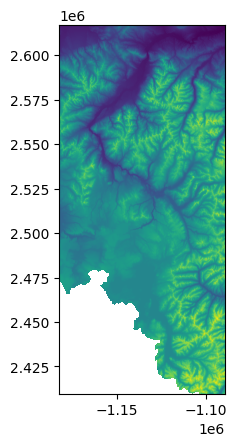

<Axes: >

In [7]:
rstr_file = flopy.utils.Raster.load(clp_elev_pth)
rstr_file.plot()

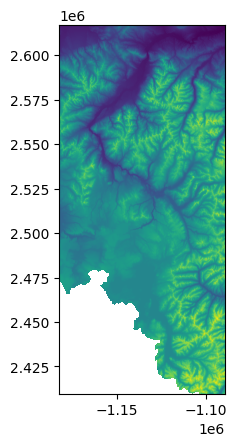

<Axes: >

In [47]:
rstr = flopy.utils.Raster(
    array=w['array'],
    bands=w['bands'],
    crs=w['crs'],
    transform=w['transform'],
    nodataval=w['nodata'],
    driver=w['driver']
)
rstr.plot()

Load vector geometry data that defines the model domain.

In [6]:
basin = gpd.read_file(uy_basin_pth)
streams = gpd.read_file(uy_prms_segs)
streams = streams.to_crs(5071)
lakes = gpd.read_file(yl_lake)
lakes = lakes.to_crs(5071)

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(
c:\Users\CNB968\.conda\envs\prms\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


<Axes: >

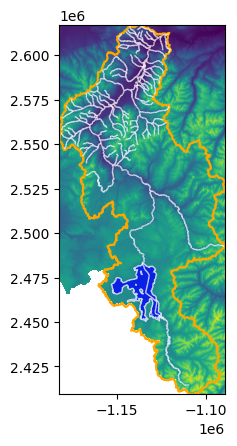

In [11]:
ax = plt.axes()
rstr.plot(ax=ax)
basin.plot(ax=ax, facecolor="None", edgecolor='orange', lw=1.5)
streams.plot(ax=ax, edgecolor='white', lw=1, alpha=0.75)
lakes.plot(ax=ax, edgecolor='white', facecolor='blue', alpha=0.75)

## Triangular Mesh & Voronoi Grid with flopy

In [12]:
tg = voronoi_grid_from_hydrography(
    basin,
    3000,
    streams,
    200,
    3,
    lakes,
    2000,
    7,
    1,
    1.3
)

Input streams have more than one geometry, dissolving geometries...


Plot the triangle grid.

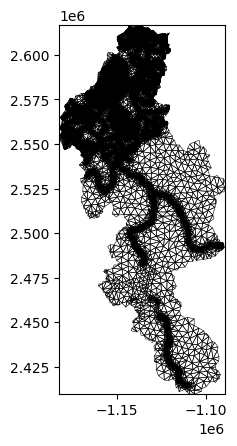

In [14]:
tg[1].plot(lw=0.4)

Save the PRMSvertexgrid object as a .grid file (it's just a json with different file extension).

In [40]:
tg[0].save_grid('UY_voronoi_grid', out_pth.resolve())

## Condition or correct Elevation data to grid

For this case, manually editing the DEM was necessary to try and match NHD flowlines (primarily for semi-accurate subbasin delineation)

Initialize a Cascades Object using the saved grid json.

In [ ]:
cascparams = PRMSCascades(out_pth / 'UY_voronoi_grid.grid')

c:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\prep\prms\params.py:45: UserWarning: There are no parameters specified yet and or no nhru dimension to check grid. Assigning grid anyway, make sure to check any inserted parameters match the grid size.
  self.grid = grid


In [ ]:
cascparams.map_hru_type(tg[2])

In [ ]:
cascparams.streams_from_hydrography(streams, segment_ids=True)

In [ ]:
grd_elev = gt.calc_zonal_stats(cascparams.grid, clp_elev_pth, stats='min', all_touched=True)
dem = np.where(grd_elev.values.ravel() == rstr.nodatavals[0], np.nan, grd_elev.values.ravel())

C:\Users\CNB968\AppData\Local\Temp\ipykernel_19464\3737489793.py:1: UserWarning: Not all geometries were returned, 15 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  grd_elev = gt.calc_zonal_stats(c.grid, clp_elev_pth, stats='min', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


In [ ]:
filled_dem = fill_voronoi_nan(dem, cascparams.grid)

Filling 76 missing grid cell values...


These grid cell elevations were manually adjusted to remove undeclared sinks along the basin boundary and force drainage paths to align to NHD flowlines for calibration subbasins.

In [261]:
# custom dem alteration to make sure Sixmile and Mill Cr line up for subbasin calculation
cepnts = {
    192: 2365,
    44896: 2365,
    191: 2365,
    2202:2365,
    190: 2365,
    6324: 2950,
    1683: 2950,
    1922: 2900,
    2189: 2900,
    1682: 2860,
    2256: 2890,
    1692: 1760,
    1927: 1760,
    1897: 1335.8,
    3918: 1335,
    2310: 1335.5,
    2690: 1336.5,
    2918: 1336.5,
    26551: 1654,
    26545: 1636.5,
    27279: 1622.5,
    27288: 1584.5,
    27200: 1572.5,
    25404: 1512.5,
    23770: 1503.5,
    27028: 1586.5,
    27288: 1586,
    27197: 1558.5,
    26959: 1547.5,
    25972: 1526,
    25966: 1521.9,
    25968: 1516.5,
    19176: 1492.5,
    1896: 1332.5,
    2482: 2975,
    2224: 2990,
    2502: 2985
}

In [262]:
edit_dem = filled_dem.copy()
for k, i in cepnts.items():
    edit_dem[k] = i

In [ ]:
conditioned_dem = dany.fill_sinks(cascparams._flopygrid, edit_dem)

In [ ]:
cascparams.map_flow_directions(conditioned_dem)

Use the find_undeclared_sinks() function which is designed to work with Dany FlowDirections array. The basin outlet will always be counted as a sink so at a minimum this function returns 1 sink.

In [ ]:
# check undeclared sinks
snks = find_undeclared_sinks(cascparams.fdir.flow_direction_array)
cascparams.fdir.flow_direction_array[snks.astype(bool)].size

1

Map Subbasins for the model domain (these will be used to calibrate).

In [266]:
pourpnts = gpd.read_file(pourpnts_pth)

In [ ]:
cascparams.map_subbasins(pourpnts)

Calculate the Cascade Links

In [ ]:
cascparams.cascades_from_hydrography()

The complete set of Cascade and Basin Parameters

In [ ]:
# need to add lake_type == 2, lake_din1, lake_init, lake_qro
cascparams.parameters

<xarray.Dataset> Size: 4MB
Dimensions:              (nhru: 45244, nsub: 19, nsegment: 1352, ncascade: 70380)
Dimensions without coordinates: nhru, nsub, nsegment, ncascade
Data variables:
    hru_type             (nhru) int64 362kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    hru_subbasin         (nhru) int64 362kB 19 19 19 19 19 19 ... 16 1 17 1 15
    lake_hru_id          (nhru) int64 362kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    hru_elev             (nhru) float64 362kB 1.794e+03 1.711e+03 ... 2.319e+03
    subbasin_down        (nsub) int64 152B 17 17 17 17 4 18 ... 18 18 11 19 18 0
    lake_segment_id      (nsegment) float64 11kB 1.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    segment_type         (nsegment) float64 11kB 2.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tosegment            (nsegment) int64 11kB 45 446 528 502 ... 892 1145 0
    hru_up_id            (ncascade) int64 563kB 1 11241 2 ... 45243 45010 45244
    hru_down_id          (ncascade) int64 563kB 11264 11264 658 ... 44992 44992
    hru_pct_up           (ncascade) float64 563kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    hru_strmseg_down_id  (ncascade) int64 563kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0

The various model domain geometries can be exported to check for inaccuracies.

In [ ]:
cascparams.export_stream_segments(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\prms_segments.shp'))

C:\Users\CNB968\AppData\Local\Temp\ipykernel_19464\1926167260.py:538: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stm_out.to_file(filename)


In [ ]:
cascparams.export_cascades_grid(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\UY_prms_grid.shp'), ['hru_type', 'hru_subbasin', 'hru_elev', 'lake_hru_id'], flow_directions=True, flow_accum=True)

C:\Users\CNB968\AppData\Local\Temp\ipykernel_19464\1926167260.py:511: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  out.to_file(filename)


## Get Meteorology Inputs

In [7]:
basin_bounds = basin.to_crs(4326).bounds
met_bbox = BBox(basin_bounds.loc[0,'minx'], basin_bounds.loc[0,'maxx'], basin_bounds.loc[0,'maxy'], basin_bounds.loc[0,'miny'])
p = GridMet('pr', start='2020-01-01', end='2024-12-31', bbox=met_bbox).subset_nc(return_array=True)
tmin = GridMet('tmmn', start='2020-01-01', end='2024-12-31', bbox=met_bbox).subset_nc(return_array=True)
tmax = GridMet('tmmx', start='2020-01-01', end='2024-12-31', bbox=met_bbox).subset_nc(return_array=True)

In [8]:
met = xr.merge([p, tmin, tmax])

In [9]:
met

<xarray.Dataset> Size: 68MB
Dimensions:                    (lat: 44, crs: 1, lon: 35, time: 1827)
Coordinates:
  * lat                        (lat) float64 352B 45.73 45.69 ... 43.98 43.94
  * crs                        (crs) float32 4B 3.0
  * lon                        (lon) float64 280B -111.1 -111.1 ... -109.7
  * time                       (time) datetime64[ns] 15kB 2020-01-01 ... 2024...
Data variables:
    precipitation_amount       (time, lat, lon) float64 23MB ...
    daily_minimum_temperature  (time, lat, lon) float64 23MB ...
    daily_maximum_temperature  (time, lat, lon) float64 23MB ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.0
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 March 2025
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

Gather elevation data that overlaps the meteorology datasets (in this case 30m SRTM derived elevation). Also do necessary unit conversions.

In [9]:
bnds = met.rio.bounds()
met_clip = gpd.GeoDataFrame(geometry=[Polygon([(bnds[0], bnds[1]), (bnds[0], bnds[3]), (bnds[2], bnds[3]), (bnds[2], bnds[1])])], crs=met.rio.crs)
met_elev = load_raster_window(met_clip, mt_elev_pth, output='xarray')
met_elev.name = 'elevation'
nan_msk = np.where(met_elev.values[0] == 0, np.nan, met_elev.values[0])
new_elev = np.array([nan_msk])
met_elev.values = new_elev
met['daily_maximum_temperature'].values = met.daily_maximum_temperature - 273.15
met['daily_minimum_temperature'].values = met.daily_minimum_temperature - 273.15

Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...


In [11]:
met_elev

<xarray.DataArray 'elevation' (band: 1, y: 7306, x: 4823)> Size: 282MB
array([[[1550., 1550., 1551., ..., 1293., 1292., 1292.],
        [1552., 1553., 1552., ..., 1291., 1291., 1290.],
        [1553., 1553., 1551., ..., 1290., 1289., 1289.],
        ...,
        [  nan,   nan,   nan, ..., 3810., 3818., 3847.],
        [  nan,   nan,   nan, ..., 3821., 3838., 3846.],
        [  nan,   nan,   nan, ..., 3827., 3838., 3835.]]])
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 39kB -1.208e+06 -1.208e+06 ... -1.063e+06
  * y            (y) float64 58kB 2.624e+06 2.624e+06 ... 2.404e+06 2.404e+06
    spatial_ref  int64 8B 0
Attributes: (12/14)
    AREA_OR_POINT:           Area
    DataType:                Elevation
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  72671.6349352779
    STATISTICS_MAXIMUM:      4213
    STATISTICS_MEAN:         48.923780890762
    ...                      ...
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       269.5767700216
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              0

Create new parameter object to populate with meterology based parameters. In this case, Gridded Meterology data will be distributed where each cell is treated as a weather station. The gridded dataset values are assigned to the model grid based on their intersection with the meteorology grid.

In [10]:
met_params = PRMSParameters(grid=out_pth / 'UY_voronoi_grid.grid')
met_params = temp_1sta_from_gridded(met, met_elev, param_obj=met_params)

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\prep\prms\params.py:46: UserWarning: There are no parameters specified yet and or no nhru dimension to check grid. Assigning grid anyway, make sure to check any inserted parameters match the grid size.
  self.grid = grid


View the resulting meterology parameter object (the first entry in the returned tuple).

In [15]:
met_params[0].parameters

<xarray.Dataset> Size: 35MB
Dimensions:              (nhru: 45244, one: 1, nmonths: 12, ntemp: 705)
Dimensions without coordinates: nhru, one, nmonths, ntemp
Data variables: (12/14)
    hru_psta             (nhru) int64 362kB 3 5 5 6 6 7 ... 646 273 248 249 403
    hru_tsta             (nhru) int64 362kB 3 5 5 6 6 7 ... 646 273 248 249 403
    max_missing          (one) int64 8B 3
    rain_adj             (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    snow_adj             (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tmax_adj             (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                   ...
    tmax_allsnow         (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    temp_units           (one) int64 8B 1
    precip_units         (one) int64 8B 1
    tsta_elev            (ntemp) float64 6kB 1.833e+03 1.627e+03 ... 2.403e+03
    tmin_lapse           (nmonths, nhru) float64 4MB 3.335 -2.313 ... 2.527
    tmax_lapse           (nmonths, nhru) float64 4MB -4.791 -4.259 ... -6.358

Going to add the jh_coef_hru parameter here as well because it is estimated using min and max temperature data. Pygsflow has builder methods to calculate this.

In [ ]:
tmin_wrm_hru, tmax_wrm_hru = mean_temp_warmest_month_by_hru(met_params[1], met_params[0].parameters.hru_tsta.values)
jh_temperature_coefficient(cascparams.parameters.hru_elev.values, tmin_wrm_hru, tmax_wrm_hru, elev_scalar=3.281)


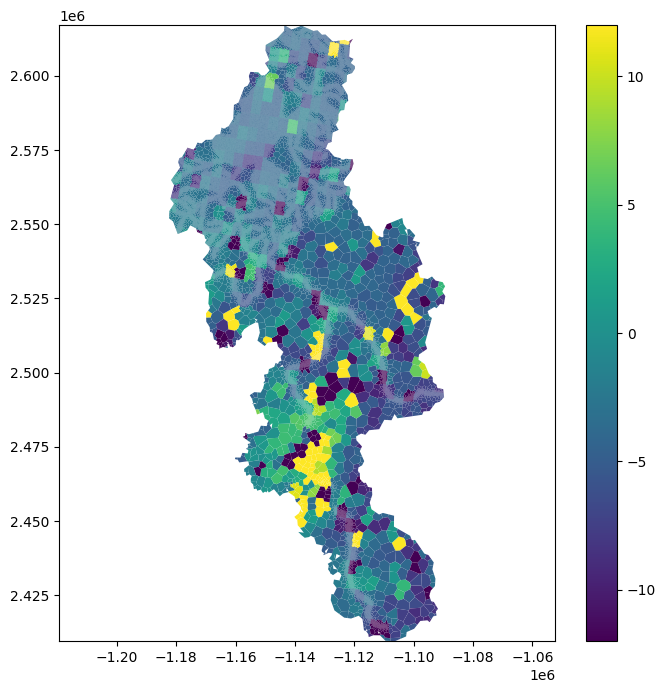

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=met_params[0]._flopygrid, ax=ax)
pc = pmv.plot_array(met_params[0].parameters.tmax_lapse.values[1,:])
fig.colorbar(pc, ax=ax)

View the PRMS Data Object with meteorology "station" data (the second entry in the returned tuple).

In [16]:
met_params[1].data_df

,Year,Month,Day,Hour,Minute,Second,tmax_0,tmax_1,tmax_2,tmax_3,...,precip_696,precip_697,precip_698,precip_699,precip_700,precip_701,precip_702,precip_703,precip_704,Date
0,2020,1,1,0,0,0,-0.75,0.05,1.95,3.25,...,15.1,16.4,16.5,17.9,15.1,12.4,16.7,16.0,14.0,2020-01-01
1,2020,1,2,0,0,0,-3.85,-2.95,-0.35,1.25,...,2.5,2.8,3.3,3.7,3.7,3.4,3.0,3.6,3.1,2020-01-02
2,2020,1,3,0,0,0,1.65,2.55,4.25,5.15,...,2.0,2.0,2.1,2.3,2.1,1.9,1.6,1.9,1.7,2020-01-03
3,2020,1,4,0,0,0,2.35,3.65,5.15,5.75,...,4.6,5.4,5.8,6.4,5.8,4.9,5.8,6.2,5.6,2020-01-04
4,2020,1,5,0,0,0,-4.95,-4.35,-2.05,-0.55,...,2.4,2.5,2.2,2.0,1.4,1.0,2.8,2.1,1.5,2020-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024,12,27,0,0,0,-2.65,-1.45,2.05,3.25,...,4.1,3.3,2.7,2.6,2.2,2.1,2.6,2.0,2.2,2024-12-27
1823,2024,12,28,0,0,0,-1.25,0.15,3.65,4.75,...,10.5,9.3,8.3,8.5,8.0,8.3,8.8,8.6,8.7,2024-12-28
1824,2024,12,29,0,0,0,-0.05,0.05,2.65,3.15,...,22.2,19.2,17.0,18.2,16.8,16.6,17.3,16.2,17.9,2024-12-29
1825,2024,12,30,0,0,0,-6.05,-5.85,-3.45,-2.65,...,2.4,2.0,1.8,2.2,1.8,1.8,2.0,1.8,1.9,2024-12-30


## Land Cover, Soils, and Canopy Parameters from Landfire, NLCD, and SSURGO

Load in Raster datasets

In [27]:
lf_vegtype_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/LANDFIRE/LF2023_EVT_240_CONUS/Tif/LC23_EVT_240.tif')
lf_cover_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/LANDFIRE/LF2023_EVC_240_CONUS/Tif/LC23_EVC_240.tif')
nlcdimperv_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/NLCD/nlcd_2019_impervious_l48_20210604/nlcd_2019_impervious.tif')
awc_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/awc_huc6_MT_intersect_dissolve_7MAR2022.tif')
ksat_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/ksat_huc6_MT_intersect_dissolve_7MAR2022.tif')
sand_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/sand_huc6_MT_intersect_dissolve_7MAR2022.tif')
clay_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/clay_huc6_MT_intersect_dissolve_7MAR2022.tif')

In [76]:
lf_vtype = load_raster_window(basin, lf_vegtype_pth, output='xarray')
lf_vtype.name = 'vegetation_type'
lf_cov = load_raster_window(basin, lf_cover_pth, output='xarray')
lf_cov.name = 'vegetation_cover'
nlcdimperv = load_raster_window(basin, nlcdimperv_pth, output='xarray')
nlcdimperv.name = 'impervious_fraction'
# as a proportion
nlcdimperv = nlcdimperv / 100
awc = load_raster_window(basin, awc_pth, output='xarray')
awc.name = 'awc'
# awc is a fraction units don't matter SSURGO states cm/cm
# wasn't sure what the scale factor was but comparing this data to Web Soil Survey, /100 provides matching fractions
awc = awc / 100
ksat = load_raster_window(basin, ksat_pth, output='xarray')
ksat.name = 'ksat'
ksat = ksat / 10000
# ksat must be in inches/day - convert from micrometer/second
ksat = ksat * 86400.0 / 25400.0
clay = load_raster_window(basin, clay_pth, output='xarray')
clay.name = 'clay'
clay = clay / 10000
sand= load_raster_window(basin, sand_pth, output='xarray')
sand.name = 'sand'
sand = sand / 10000

Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...
Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...
Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...


Start a new Parameter Object to hold soil, canopy, and drainage parameters.

In [77]:
soilparams = PRMSParameters(grid=out_pth / 'UY_voronoi_grid.grid')

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\prep\prms\params.py:46: UserWarning: There are no parameters specified yet and or no nhru dimension to check grid. Assigning grid anyway, make sure to check any inserted parameters match the grid size.
  self.grid = grid


Resample all rasters to model grid.

In [78]:
mod_vtype = gt.calc_zonal_stats(soilparams.grid, lf_vtype, stats=[lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else np.nan], all_touched=True)
mod_vtype = mod_vtype.values.ravel()
mod_vcov = gt.calc_zonal_stats(soilparams.grid, lf_cov, stats=[lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else np.nan], all_touched=True)
mod_vcov = mod_vcov.values.ravel()
mod_imperv = gt.calc_zonal_stats(soilparams.grid, nlcdimperv, stats='mean', all_touched=True)
mod_imperv = mod_imperv.values.ravel()
mod_awc = gt.calc_zonal_stats(soilparams.grid, awc, stats='median', all_touched=True)
mod_awc = mod_awc.values.ravel()
mod_ksat = gt.calc_zonal_stats(soilparams.grid, ksat, stats='median', all_touched=True)
mod_ksat = mod_ksat.values.ravel()
mod_clay = gt.calc_zonal_stats(soilparams.grid, clay, stats='median', all_touched=True)
mod_clay = mod_clay.values.ravel()
mod_sand = gt.calc_zonal_stats(soilparams.grid, sand, stats='median', all_touched=True)
mod_sand = mod_sand.values.ravel()

C:\Users\CNB968\AppData\Local\Temp\ipykernel_28052\2468226179.py:1: UserWarning: Not all geometries were returned, 16 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_vtype = gt.calc_zonal_stats(soilparams.grid, lf_vtype, stats=[lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else np.nan], all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\AppData\Local\Temp\ipykernel_28052\2468226179.py:3: UserWarning: Not all geometries were returned, 16 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_vcov = gt.calc_zonal_stats(soilparams.grid, lf_cov, stats=[lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else np.nan], all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\AppData\Local\Temp\ipykernel_28052\2468226179.py:5: UserWarning: Not all geometries were returned, 20 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_imperv = gt.calc_zonal_stats(soilparams.grid, nlcdimperv, stats='mean', all_touched=True)


...

Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\AppData\Local\Temp\ipykernel_28052\2468226179.py:11: UserWarning: Not all geometries were returned, 17 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_clay = gt.calc_zonal_stats(soilparams.grid, clay, stats='median', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\AppData\Local\Temp\ipykernel_28052\2468226179.py:13: UserWarning: Not all geometries were returned, 17 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_sand = gt.calc_zonal_stats(soilparams.grid, sand, stats='median', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


Use the remap files to convert vegetation rasters to PRMS integer category values.

In [79]:

covtype_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/covtype2022.rmp')
covdensum_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/covdensum2022.rmp')
covdenwin_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/covdenwin.rmp')
rtdepth_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/rtdepth2022.rmp')
snowintcp_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/snow_intcp2022.rmp')
srainintcp_lut = bu.build_lut(pckg_pth / 'prep/static/raster_remaps/landfire/srain_intcp2022.rmp')

Use pygsflow builder_utils to construct the various soil, canopy, and drainage parameters. Then add each one to the initialized parameter class.

In [ ]:
covtype = bu.covtype(mod_vtype, covtype_lut)
soilparams.add_parameter(
    'cov_type',
    covtype.values,
    covtype._dimensions[0][1],
    covtype._dimensions[0][0]
)

covden_sum = bu.covden_sum(mod_vcov, covdensum_lut)
soilparams.add_parameter(
    'covden_sum',
    covden_sum.values,
    covden_sum._dimensions[0][1],
    covden_sum._dimensions[0][0]
)

covden_win = bu.covden_win(covtype.values, covdenwin_lut)
soilparams.add_parameter(
    'covden_win',
    covden_win.values,
    covden_win._dimensions[0][1],
    covden_win._dimensions[0][0]
)

rad_trncf = bu.rad_trncf(covden_win.values)
soilparams.add_parameter(
    'rad_trncf',
    rad_trncf.values,
    rad_trncf._dimensions[0][1],
    rad_trncf._dimensions[0][0]
)

snow_intcp = bu.snow_intcp(mod_vtype, snowintcp_lut)
soilparams.add_parameter(
    'snow_intcp',
    snow_intcp.values,
    snow_intcp._dimensions[0][1],
    snow_intcp._dimensions[0][0]
)

srain_intcp = bu.srain_intcp(mod_vtype, srainintcp_lut)
soilparams.add_parameter(
    'srain_intcp',
    srain_intcp.values,
    srain_intcp._dimensions[0][1],
    srain_intcp._dimensions[0][0]
)

wrain_intcp = bu.wrain_intcp(mod_vtype, snowintcp_lut)
soilparams.add_parameter(
    'wrain_intcp',
    wrain_intcp.values,
    wrain_intcp._dimensions[0][1],
    wrain_intcp._dimensions[0][0]
)

# defaults for fastcoef_lin, fastcoef_sq, slowcoef_lin, slowcoef_sq, soil2gw_max, ssr2gw_exp, ssr2gw_rate, soil_rechr_max_frac, gwflow_coef, gwsink_coef, gwstor_init, gwstor_min these will be calibration parameters
rtdepth = bu.root_depth(mod_vtype, rtdepth_lut)
soil_type = bu.soil_type(mod_clay, mod_sand)
soil_moistmx = bu.soil_moist_max(mod_awc, rtdepth)

soilparams.add_parameter(
    "soil_type",
    soil_type.values,
    soil_type._dimensions[0][1],
    soil_type._dimensions[0][0]
)

soilparams.add_parameter(
    "soil_moist_max",
    soil_moistmx.values,
    soil_moistmx._dimensions[0][1],
    soil_moistmx._dimensions[0][0]
)

# use 10% of soil_moist_max for initial fraction
# This says for model_mode=PRMS5 I think this carries over to v6 as docs don't say there is a PRMS6 model_mode
soilparams.add_parameter(
    "soil_moist_init_frac",
    np.ones(len(soilparams.grid)) * 0.1,
    len(soilparams.grid),
    'nhru'
)

#ssstor_init_frac, again use 10%
soilparams.add_parameter(
    "ssstor_init_frac",
    np.ones(len(soilparams.grid)) * 0.1,
    len(soilparams.grid),
    'nhru'
)

# stick with 10% initial fraction of water in capillary reservoir where losses from ET occur
soilparams.add_parameter(
    "soil_rechr_init_frac",
    np.ones(len(soilparams.grid)) * 0.1,
    len(soilparams.grid),
    'nhru'
)

mod_imperv[np.isnan(mod_imperv)] = np.nanmean(mod_imperv)
soilparams.add_parameter(
    "hru_percent_imperv",
    mod_imperv,
    len(mod_imperv),
    'nhru'
)

soilparams.add_parameter(
    "carea_max",
    1 - mod_imperv,
    len(mod_imperv),
    'nhru'
)

# add gwstor_init here with default value
soilparams.add_parameter(
    "gwstor_init",
    np.ones(len(soilparams.grid)) * 2.0,
    len(soilparams.grid),
    'ngw'
)

In [81]:
soilparams.parameters

<xarray.Dataset> Size: 5MB
Dimensions:               (nhru: 45244)
Dimensions without coordinates: nhru
Data variables: (12/14)
    cov_type              (nhru) int64 362kB 2 2 2 1 2 2 2 1 ... 4 4 4 1 4 4 4 4
    covden_sum            (nhru) float64 362kB 0.32 0.28 0.28 ... 0.1 0.55 0.41
    covden_win            (nhru) float64 362kB 0.4 0.4 0.4 0.6 ... 1.0 1.0 1.0
    rad_trncf             (nhru) float64 362kB 0.3294 0.3294 ... 0.06304 0.06304
    snow_intcp            (nhru) float64 362kB 0.01 0.01 0.01 ... 0.05 0.05 0.05
    srain_intcp           (nhru) float64 362kB 0.02 0.02 0.02 ... 0.04 0.04 0.04
    ...                    ...
    soil_moist_max        (nhru) float64 362kB 3.0 3.0 3.0 3.0 ... 3.0 3.6 3.0
    soil_moist_init_frac  (nhru) float64 362kB 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1
    ssstor_init_frac      (nhru) float64 362kB 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1
    soil_rechr_init_frac  (nhru) float64 362kB 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1
    hru_percent_imperv    (nhru) float64 362kB 0.0 0.0 0.0 ... 0.0 0.0 1.254e-06
    carea_max             (nhru) float64 362kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0

In [70]:
soilparams.parameters.hru_percent_imperv.max()

<xarray.DataArray 'hru_percent_imperv' ()> Size: 8B
array(83.07142857)

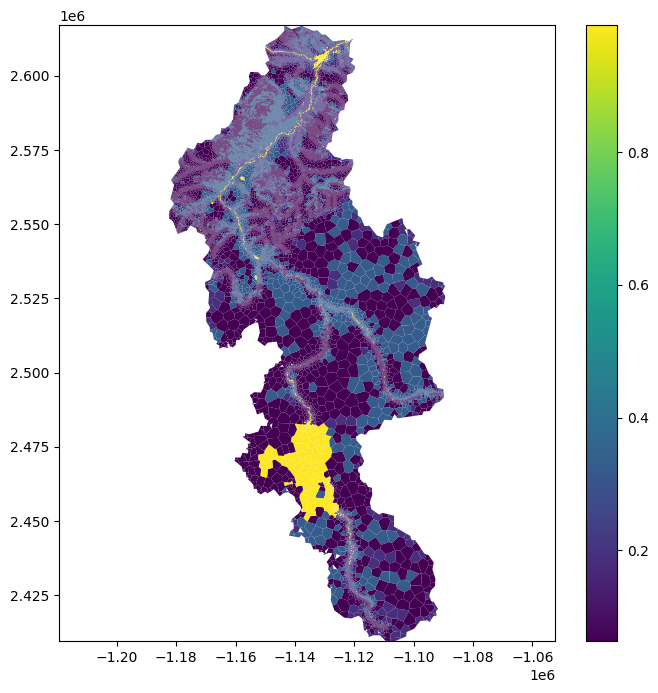

In [86]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=soilparams._flopygrid, ax=ax)
pc = pmv.plot_array(soilparams.parameters.rad_trncf.values)
fig.colorbar(pc, ax=ax)

## Create Parameter Object for calibration parameters

In [ ]:
calibparams = PRMSParameters(grid=out_pth / 'UY_voronoi_grid.grid')

All of these parameters will initially be set as default values and then adjusted during the calibration procedure.
- fastcoef_lin
- fastcoef_sq
- slowcoef_lin
- slowcoef_sq
- soil2gw_max
- ssr2gw_exp
- ssr2gw_rate
- soil_rechr_max_frac,
- gwflow_coef
- gwsink_coef
- gwstor_min
- pref_flow_den
- pref_flow_infil_frac
- sat_threshold
- K_coef
- x_coef
- lake_coef
- adjmix_rain

In [ ]:
# defaults for fastcoef_lin, fastcoef_sq, slowcoef_lin, slowcoef_sq, soil2gw_max, ssr2gw_exp, ssr2gw_rate, soil_rechr_max_frac, gwflow_coef, gwsink_coef, gwstor_init, gwstor_min these will be calibration parameters
calibparams.add_parameter(
    'fastcoef_lin',
    np.ones(len(calibparams.grid)) * 0.1,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'fastcoef_sq',
    np.ones(len(calibparams.grid)) * 0.8,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'slowcoef_lin',
    np.ones(len(calibparams.grid)) * 0.015,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'slowcoef_sq',
    np.ones(len(calibparams.grid)) * 0.1,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'soil2gw_max',
    np.ones(len(calibparams.grid)) * 0.0,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'ssr2gw_exp',
    np.ones(len(calibparams.grid)) * 1.0,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'ssr2gw_rate',
    np.ones(len(calibparams.grid)) * 0.1,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'soil_rechr_max_frac',
    np.ones(len(calibparams.grid)) * 1.0,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'gwflow_coef',
    np.ones(len(calibparams.grid)) * 0.015,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'gwsink_coef',
    np.ones(len(calibparams.grid)) * 0.0,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'gwstor_min',
    np.ones(len(calibparams.grid)) * 0.0,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'pref_flow_den',
    np.ones(len(calibparams.grid)) * 0.0,
    len(calibparams.grid),
    'nhru'
)

calibparams.add_parameter(
    'pref_flow_infil_frac',
    np.ones(len(calibparams.grid)) * -1.0,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'sat_threshold',
    np.ones(len(calibparams.grid)) * 999.0,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'K_coef',
    np.ones(len(calibparams.grid)) * 1.0,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'x_coef',
    np.ones(len(calibparams.grid)) * 0.2,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'lake_coef',
    np.ones(len(calibparams.grid)) * 0.1,
    len(calibparams.grid),
    'ngw'
)

calibparams.add_parameter(
    'adjmix_rain',
    np.ones(12, len(calibparams.grid)) * 1.0,
    [12, len(calibparams.grid)],
    ['nmonths', 'nhru']
)

These parameters will be set by alignment with GridMET solar radiation, but for now will take on default values:
- dday_intcp
- dday_slope
- ppt_rad_adj
- radj_sppt
- radj_wppt
- radmax
- tmax_index

In [21]:
soilparams.parameters

<xarray.Dataset> Size: 724kB
Dimensions:     (nhru: 45244)
Dimensions without coordinates: nhru
Data variables:
    cov_type    (nhru) int64 362kB 2 2 2 1 2 2 2 1 4 1 1 ... 4 4 4 4 4 1 4 4 4 4
    covden_sum  (nhru) float64 362kB 0.32 0.28 0.28 0.1 ... 0.1 0.1 0.55 0.41

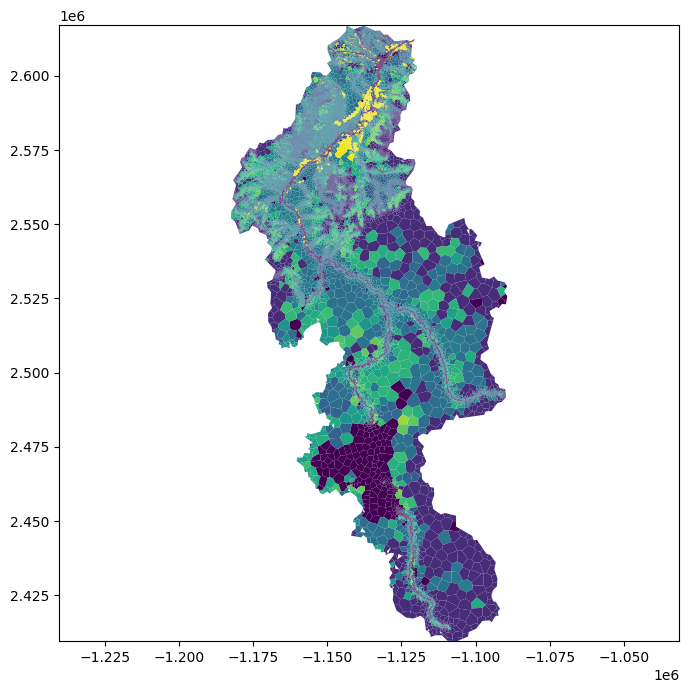

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=soilparams._flopygrid, ax=ax)
pc = pmv.plot_array(covden_sum.values)

In [13]:
np.nanmean(nlcdimperv.values)

np.float64(0.2237005351943567)

In [83]:
with rio.open(nlcdimperv_pth) as f:
    m = f.crs

In [87]:
m.to_epsg()

In [60]:
grid_vec = gt.utils.vectorize_grid(met)
grid_vec = grid_vec.to_crs(t.grid.crs)
grid_cent = t.grid.copy()
grid_cent['geometry'] = t.grid.centroid
insct = grid_cent.sjoin(grid_vec, predicate='within')

In [72]:
gt.calc_zonal_stats(grid_vec, met_elev, stats=[lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else np.nan], all_touched=True)

,,,elevation
FID,band,stat,
0,1,<lambda>,1375.0
1,1,<lambda>,1385.0
2,1,<lambda>,1417.0
3,1,<lambda>,1543.0
4,1,<lambda>,1853.0
...,...,...,...
1535,1,<lambda>,2966.0
1536,1,<lambda>,3008.0
1537,1,<lambda>,2553.0


In [40]:
grid_elev = gt.calc_zonal_stats(grid_vec, met_elev, stats='median', all_touched=True)
stn_elev = grid_elev.loc[(insct['index_right'].values, 1, 'median'),:]

In [30]:
stn_elev = grid_elev.loc[(insct['index_right'].values, 1, 'median'),:]

In [43]:
stn_elev.values.ravel().size

705

In [37]:
grid_elev.values.ravel()[insct['index_right'].values]

array([1833., 1627., 1627., ..., 2809., 2508., 2403.])

In [11]:
gvec_sel = grid_vec.loc[insct['index_right'].unique()]
gvec_sel.sort_index(inplace=True)
gvec_sel.reset_index(inplace=True)
met_keys = pd.Series(gvec_sel.index, index=gvec_sel['index']).to_dict()

In [12]:
insct['station_id'] = insct['index_right'].replace(met_keys) + 1

In [99]:
insct

,geometry,index_right,station_id
0,POINT (-1137724.852 2616665.697),11,3
1,POINT (-1133736.208 2615086.367),13,5
2,POINT (-1132424.57 2615265.547),13,5
3,POINT (-1130890.86 2613804.093),14,6
4,POINT (-1129760.387 2613848.945),14,6
...,...,...,...
45239,POINT (-1113437.987 2435733.764),1322,646
45240,POINT (-1113768.599 2538745.482),582,273
45241,POINT (-1114779.239 2542014.108),547,248
45242,POINT (-1111651.094 2541032.708),548,249


In [13]:
outgrid = t.grid.copy()
outgrid['hru_psta'] = insct['station_id'].values

<Axes: >

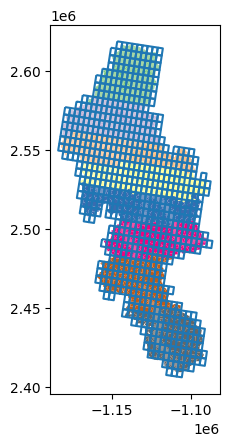

In [18]:
ax = plt.axes()
outgrid.plot(ax=ax, column='hru_psta', cmap='Accent')
gvec_sel.boundary.plot(ax=ax)

In [13]:
temp_units='celcius'  # 0 = fahrenheit; 1 = celcius
precip_units='mm' # 0 = inches; 1 = mm

if temp_units == 'celcius':
    tmpu = 1
elif temp_units == 'fahrenheit':
    tmpu = 0
else:
    raise ValueError("The temperature units are not recognized or are mispelled, use 'fahrenheit' or 'celcius'")

if precip_units == 'mm':
    pru = 1
elif precip_units == 'inches':
    pru = 0
else:
    raise ValueError("The precip units are not recognized or are mispelled, use 'inches' or 'mm'")

t.add_parameter(
    'hru_psta',
    insct['station_id'].values,
    len(insct),
    'nhru'
)

t.add_parameter(
    'hru_tsta',
    insct['station_id'].values,
    len(insct),
    'nhru'
)

t.add_parameter(
    'max_missing',
    np.array([3]),
    1,
    'one'
)

t.add_parameter(
    'rain_adj',
    np.zeros((12, len(t.grid))),
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'snow_adj',
    np.zeros((12, len(t.grid))),
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'tmax_adj',
    np.zeros((12, len(t.grid))),
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'tmin_adj',
    np.zeros((12, len(t.grid))),
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'tmax_allrain_offset',
    np.zeros((12, len(t.grid))),
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'tmax_allsnow',
    np.ones((12, len(t.grid))) * 32.0,
    [12, len(t.grid)],
    ['nmonths', 'nhru']
)

t.add_parameter(
    'temp_units',
    np.array([tmpu]),
    1,
    'one'
)

t.add_parameter(
    'precip_units',
    np.array([pru]),
    1,
    'one'
)

In [ ]:
bnds = grid_vec.total_bounds
met_clip = gpd.GeoDataFrame(geometry=[Polygon([(bnds[0], bnds[1]), (bnds[0], bnds[3]), (bnds[2], bnds[3]), (bnds[2], bnds[1])])], crs=grid_vec.crs)
met_elev = load_raster_window(met_clip, mt_elev_pth, output='xarray')
met_elev.name = 'elevation'
nan_msk = np.where(met_elev.values[0] == 0, np.nan, met_elev.values[0])
new_elev = np.array([nan_msk])
met_elev.values = new_elev
mxtemp = met.daily_maximum_temperature
mxtemp = mxtemp - 273.15
mxt = mxtemp.rio.set_crs(met.rio.crs)

In [ ]:
lr = lapse_rates_from_gridded(mxt, met_elev)

In [29]:
t.parameters.tmin_adj[0]

<xarray.DataArray 'tmin_adj' (nhru: 45244)> Size: 362kB
array([0., 0., 0., ..., 0., 0., 0.])
Dimensions without coordinates: nhru
Attributes:
    default:  0
    desc:     HRU minimum temperature adjustment
    help:     Adjustment to minimum temperature for each HRU, estimated on th...
    maximum:  10
    minimum:  -10
    modules:  ['temp_1sta', 'temp_laps', 'temp_dist2', 'ide_dist', 'xyz_dist']
    type:     F
    units:    temp_units
    dims:     ('nmonth', 'nhru')

In [45]:
met_t, met_r, met_c = met.precipitation_amount.values.shape
met_shape = (met_r, met_c)

In [46]:
station_idx = np.unravel_index(gvec_sel['index'].values, met_shape)

In [59]:
insct['index_right'].values

array([ 11,  13,  13, ..., 547, 548, 778])

In [60]:
modgrid_idx = np.unravel_index(insct['index_right'].values, met_shape)

In [49]:
station_idx[1]

array([ 9, 10, 11, 12, 13, 14, 15, 16, 17,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  8,  9, 10, 11, 12,
       13, 14, 15, 16, 17,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  6,
        7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  6,  7,  8,  9, 10, 11,
       12, 13, 14, 15, 16, 17,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
       14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26, 27

In [63]:
lr.values[:,modgrid_idx[0], modgrid_idx[1]].shape

(12, 45244)

In [20]:
vars = list(met.data_vars)
var_names = {}
for v in vars:
    if check_precip_string(v):
        var_names.update({v: 'precip'})
    elif check_min_temp_string(v):
        var_names.update({v: 'tmin'})
    elif check_max_temp_string(v):
        var_names.update({v: 'tmax'})
    else:
        raise ValueError(f"Variable name {v} not recognized as precipitation, minimum temperature, or maximum temperature.")

In [22]:
met.rename(var_names)

<xarray.Dataset> Size: 68MB
Dimensions:  (lat: 44, crs: 1, lon: 35, time: 1827)
Coordinates:
  * lat      (lat) float64 352B 45.73 45.69 45.65 45.61 ... 44.03 43.98 43.94
  * crs      (crs) float32 4B 3.0
  * lon      (lon) float64 280B -111.1 -111.1 -111.1 ... -109.8 -109.8 -109.7
  * time     (time) datetime64[ns] 15kB 2020-01-01 2020-01-02 ... 2024-12-31
Data variables:
    precip   (time, lat, lon) float64 23MB 0.7 0.7 2.0 6.7 ... 0.0 0.0 0.0 0.0
    tmin     (time, lat, lon) float64 23MB 273.5 273.4 273.1 ... 255.7 256.5
    tmax     (time, lat, lon) float64 23MB 277.9 277.7 277.3 ... 264.8 265.0
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.0
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 March 2025
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [100]:
pd.DataFrame(met.precipitation_amount.values[:,station_idx[0], station_idx[1]])

,0,1,2,3,4,5,6,7,8,9,...,695,696,697,698,699,700,701,702,703,704
0,10.9,9.3,4.7,1.6,0.3,0.0,0.0,0.0,0.0,7.9,...,12.9,15.1,16.4,16.5,17.9,15.1,12.4,16.7,16.0,14.0
1,0.6,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,...,3.8,2.5,2.8,3.3,3.7,3.7,3.4,3.0,3.6,3.1
2,0.5,0.7,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.6,2.0,2.0,2.1,2.3,2.1,1.9,1.6,1.9,1.7
3,0.5,0.5,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.3,...,4.9,4.6,5.4,5.8,6.4,5.8,4.9,5.8,6.2,5.6
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.2,2.4,2.5,2.2,2.0,1.4,1.0,2.8,2.1,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,0.9,0.8,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.7,4.1,3.3,2.7,2.6,2.2,2.1,2.6,2.0,2.2
1823,3.4,2.7,1.1,0.4,0.0,0.0,0.0,0.0,0.0,1.4,...,14.4,10.5,9.3,8.3,8.5,8.0,8.3,8.8,8.6,8.7
1824,16.4,14.7,9.9,7.3,5.5,3.6,3.2,3.4,4.2,9.3,...,27.7,22.2,19.2,17.0,18.2,16.8,16.6,17.3,16.2,17.9
1825,13.8,12.6,7.5,3.6,0.8,0.0,0.0,0.0,0.0,7.6,...,2.9,2.4,2.0,1.8,2.2,1.8,1.8,2.0,1.8,1.9


In [14]:
bnds = grid_vec.total_bounds
met_clip = gpd.GeoDataFrame(geometry=[Polygon([(bnds[0], bnds[1]), (bnds[0], bnds[3]), (bnds[2], bnds[3]), (bnds[2], bnds[1])])], crs=grid_vec.crs)

In [15]:
met_elev = load_raster_window(met_clip, mt_elev_pth, output='xarray')
met_elev.name = 'elevation'
nan_msk = np.where(met_elev.values[0] == 0, np.nan, met_elev.values[0])
new_elev = np.array([nan_msk])
met_elev.values = new_elev

<Axes: title={'center': 'band = 1, spatial_ref = 0'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>

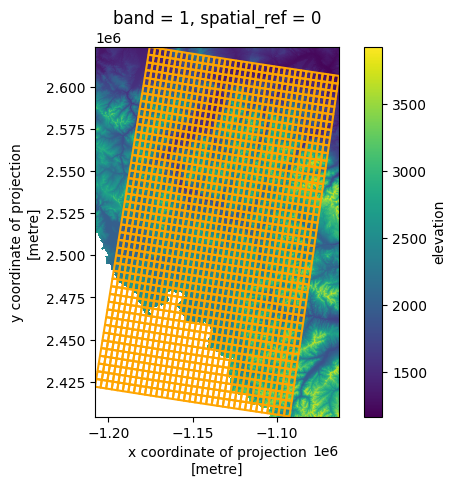

In [110]:
ax = plt.axes()
met_elev.isel(band=0).plot(ax=ax)
grid_vec.plot(ax=ax, facecolor="None", edgecolor='orange', lw=1.5)

In [16]:
mxtemp = met.daily_maximum_temperature
mxtemp = mxtemp - 273.15
mxt = mxtemp.rio.set_crs(met.rio.crs)

In [18]:
lr = lapse_rates_from_gridded(mxt, met_elev)

In [19]:
lr

<xarray.DataArray 'lapse_rate' (month: 12, lat: 44, lon: 35)> Size: 148kB
array([[[ 1.03781980e+01,  7.39752607e+00,  3.42920706e+00, ...,
         -5.02530044e+00, -3.02932551e+00, -3.22580645e+00],
        [ 3.44974673e+00,  1.24460249e+00, -1.10283981e-02, ...,
         -3.60492185e+00, -1.29032258e-01, -5.53908747e+00],
        [-2.27126957e+00, -1.74432497e+00,  2.22036028e-01, ...,
         -5.81354130e-01, -5.79011842e+00, -5.34843635e+00],
        ...,
        [            nan,             nan,             nan, ...,
         -4.56118792e+00, -6.08042422e+00, -5.60827920e+00],
        [            nan,             nan,             nan, ...,
         -6.17914873e+00, -6.08565014e+00, -5.78430217e+00],
        [            nan,             nan,             nan, ...,
         -6.19158372e+00, -5.78150603e+00, -3.05123340e+00]],

       [[ 1.12918893e+01,  9.36143175e+00,  6.07090821e-01, ...,
         -6.01353217e+00, -5.03201024e+00, -6.05028018e+00],
        [ 4.13223140e+00,  2.88344239e+00,  1.20380402e-02, ...,
         -4.10919123e+00, -5.18565941e+00, -8.34284989e+00],
        [-9.76031628e-01, -1.58668058e+00, -1.49990854e+00, ...,
          8.66738895e-01, -9.60955607e+00, -7.21696592e+00],
...
        [            nan,             nan,             nan, ...,
         -7.49417989e+00, -6.32572298e+00, -6.08191126e+00],
        [            nan,             nan,             nan, ...,
         -5.90517870e+00, -6.17756846e+00, -5.88069150e+00],
        [            nan,             nan,             nan, ...,
         -5.86833856e+00, -5.62294668e+00, -4.14117647e+00]],

       [[ 1.05672970e+00, -9.94421538e-01, -2.16113142e+00, ...,
         -3.29854522e+00, -1.73313783e+00, -5.06416927e-01],
        [-8.47773927e-01, -5.02921006e-01, -1.10283981e+00, ...,
         -1.15729963e+00,  1.79472141e+00, -1.46469050e+00],
        [ 5.47066591e-01, -9.51812027e-01, -1.77209887e+00, ...,
         -1.49592343e+00, -6.54961209e+00, -4.93967003e+00],
        ...,
        [            nan,             nan,             nan, ...,
         -4.40757808e+00, -2.51878038e+00, -6.29307498e+00],
        [            nan,             nan,             nan, ...,
         -6.70431284e+00, -6.07552202e+00, -5.29088810e+00],
        [            nan,             nan,             nan, ...,
         -6.00031781e+00, -5.26694221e+00, -3.51676154e+00]]])
Coordinates:
  * lat      (lat) float64 352B 45.73 45.69 45.65 45.61 ... 44.03 43.98 43.94
  * lon      (lon) float64 280B -111.1 -111.1 -111.1 ... -109.8 -109.8 -109.7
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    temp/1000elev_units

In [210]:
mmax_elev = gt.calc_zonal_stats(grid_vec, met_elev, stats=['min', 'max', 'median'], all_touched=True)

In [211]:
mmax_elev

elevation
FID  band stat             
0    1    max        1422.0
          median     1388.0
          min        1364.0
1    1    max        1440.0
          median     1395.0
...                     ...
1538 1    median     2541.5
          min        2332.0
1539 1    max        3366.0
          median     2586.0
          min        2276.0

[4620 rows x 1 columns]

In [113]:
met_elev.shape

(1, 7306, 4823)

In [235]:
maxelev = mmax_elev.loc[(slice(None), slice(None),'max'),'elevation'].values.reshape((temp_grid.shape[1], temp_grid.shape[2]))
minelev = mmax_elev.loc[(slice(None), slice(None),'min'),'elevation'].values.reshape((temp_grid.shape[1], temp_grid.shape[2]))
medelev = mmax_elev.loc[(slice(None), slice(None),'median'),'elevation'].values.reshape((temp_grid.shape[1], temp_grid.shape[2]))
elevrng = maxelev - minelev
mxgradx, mxgrady = np.gradient(medelev)
#adjgradx = mxgradx + elevrng
#adjgrady = mxgrady + elevrng
#mn_grad = np.mean(np.array([adjgradx, adjgrady]), axis=0)
mn_grad = np.mean(np.array([mxgradx, mxgrady]), axis=0)

In [185]:
adj_elevgrad = np.where(mn_grad < 0, mn_grad - elevrng, mn_grad + elevrng)

In [131]:
mon_tmp = temp_grid.groupby("time.month").mean("time")

In [168]:
mon_tmp.month.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [236]:
month_grads = []
for m in mon_tmp.month.values-1:
    tgradx, tgrady = np.gradient(mon_tmp.values[m])
    mn_tgrad = np.mean(np.array([tgradx, tgrady]), axis=0)
    month_grads.append(mn_tgrad)

In [237]:
tgrad_arr = np.array(month_grads)
lap_rate = (tgrad_arr / np.array([mn_grad])) * 1000

In [238]:
lapse_rate = xr.DataArray(lap_rate, coords=mon_tmp.coords, dims=mon_tmp.dims)

In [239]:
lapse_rate = xr.where(lapse_rate > 12, 12, lapse_rate)
lapse_rate = xr.where(lapse_rate < -12, -12, lapse_rate)

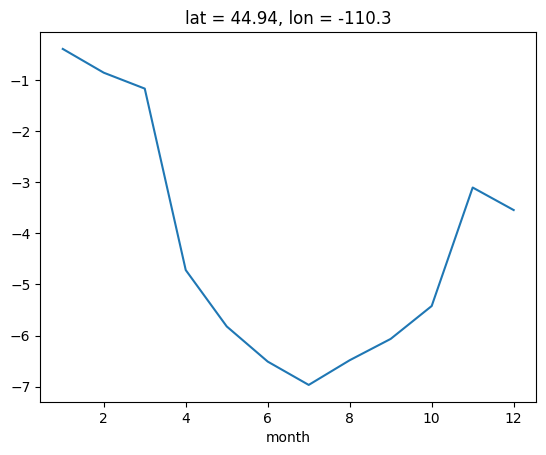

In [240]:
lapse_rate.isel(lat=19, lon=19).plot()

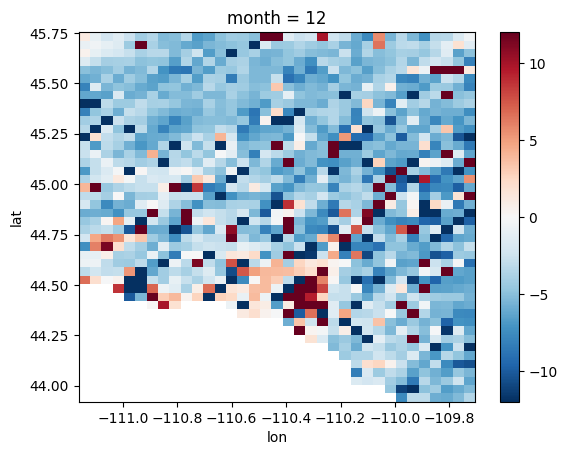

In [241]:
lapse_rate.isel(month=11).plot()

In [180]:
mon_tmp.values[0]

array([[ 0.96806452,  1.03064516,  1.12483871, ...,  3.36354839,
         3.50677419,  3.52935484],
       [ 1.50741935,  1.44419355,  1.35516129, ...,  2.70741935,
         3.09064516,  3.20677419],
       [ 1.51193548,  1.34096774,  1.29064516, ...,  2.61193548,
         3.00032258,  2.68225806],
       ...,
       [-1.21645161, -0.91580645, -1.05709677, ..., -5.25580645,
        -5.55645161, -6.17645161],
       [-1.45774194, -0.76548387, -0.54935484, ..., -5.56290323,
        -5.27451613, -3.17451613],
       [-1.44419355, -0.61580645, -0.55709677, ..., -3.79451613,
        -2.13      , -2.45774194]])

In [158]:
grid_vec['daily_maximum_temperature_lapserate_per_1000elev_units'].max()

np.float64(36.18279569892461)

In [165]:
mon_tmp.values.reshape((12, 44*35))

array([[ 0.96806452,  1.03064516,  1.12483871, ..., -3.79451613,
        -2.13      , -2.45774194],
       [ 1.13943662,  1.25070423,  1.61408451, ..., -3.36478873,
        -1.58943662, -1.89084507],
       [ 7.08032258,  7.1616129 ,  7.20870968, ...,  1.06806452,
         2.88677419,  2.39516129],
       ...,
       [14.81258065, 14.75645161, 14.7016129 , ...,  7.8616129 ,
         9.60483871,  8.98870968],
       [ 6.28933333,  6.476     ,  6.632     , ...,  0.158     ,
         1.764     ,  1.544     ],
       [ 3.24612903,  3.29129032,  3.15645161, ..., -2.64806452,
        -1.02225806, -1.27387097]])

<Axes: >

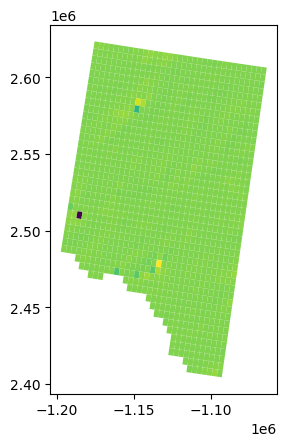

In [152]:
grid_vec.plot(column='daily_maximum_temperature_lapserate_per_1000elev_units')

In [65]:
t = gvec_sel.sjoin(gvec_sel)

In [66]:
t[t['index_left'] == 9]

,index_left,geometry,index_right0,index_right
0,9,"POLYGON ((-1146726.809 2618962.234, -1143521.6...",11,45
0,9,"POLYGON ((-1146726.809 2618962.234, -1143521.6...",10,44
0,9,"POLYGON ((-1146726.809 2618962.234, -1143521.6...",9,43
0,9,"POLYGON ((-1146726.809 2618962.234, -1143521.6...",0,9
0,9,"POLYGON ((-1146726.809 2618962.234, -1143521.6...",1,10


In [39]:
pr_da = met.precipitation_amount.isel(lon=[1,2], lat=[1,2])

In [ ]:
met.precipitation_amount.values[:,[1,2],[1,2]]

(1827, 2)

In [24]:
np.unravel_index(1539, met_shape)

(np.int64(43), np.int64(34))

In [319]:
subs_dwn = []
pnt_subs = []
for p in pourpnts.geometry.values:
    pnt_id = c.grid.intersects(p).values
    gpnt = c.grid[pnt_id].index.values
    sbp_id = subbasins[pnt_id]
    pnt_subs.append(sbp_id[0])
    pfd = c.fdir.flow_direction_array[gpnt]
    if gpnt == pfd:
        subs_dwn.append(0)
    else:
        dwn_sub = int(subbasins[pfd][0])
        subs_dwn.append(dwn_sub)
subs_dwn = np.array(subs_dwn)
pnt_subs = np.array(pnt_subs)

In [320]:
subs_dwn

array([17, 17, 17, 17,  4, 18, 18, 18, 18, 18,  9, 18, 12, 18, 18, 11, 19,
       18,  0])

In [321]:
pnt_subs

array([16,  1, 15,  4,  3,  5,  6, 13, 14,  8,  7,  9,  2, 12, 11, 10, 18,
       17, 19])

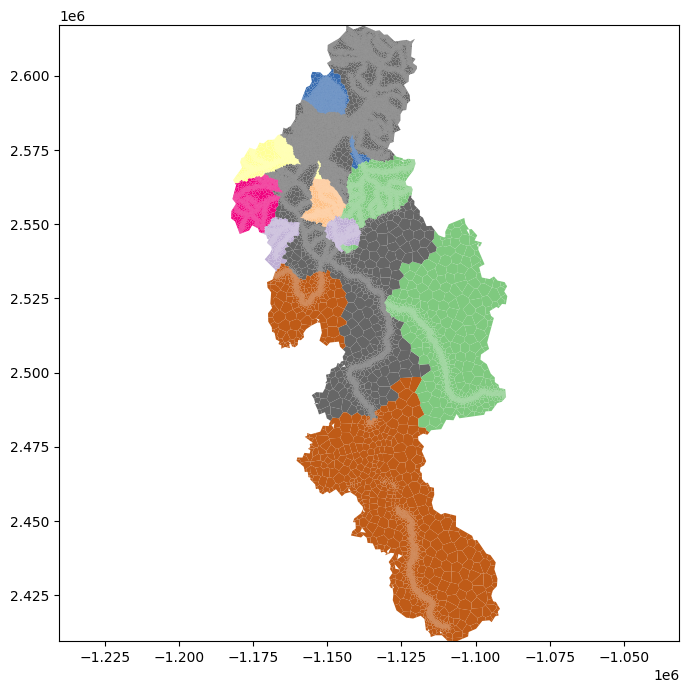

In [60]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=c._flopygrid, ax=ax)
pc = pmv.plot_array(subbasins, masked_values=[0,], cmap="Accent")

In [90]:
c.stream_grid.max()

np.int64(1615)

In [62]:
stmobj = dany.PrmsStreams(c._flopygrid, c.fdir)

In [63]:
stmcon = stmobj.get_stream_connectivity(c.stream_grid)

In [84]:
c._strm_ids

array([    7,   669,   680, ..., 44542, 44543, 44544])

In [80]:
c.stream_grid[c._strm_ids]

array([1013, 1615, 1203, ...,  270,  270,  270])

In [79]:
print(c.stream_grid[7])
print(c.fdir.flow_direction_array[7])
print(c.stream_grid[c.fdir.flow_direction_array[7]])

1013
2310
1548


In [83]:
stmobj._graph

{1: 2,
 2: 3,
 3: 4,
 4: 5,
 5: 6,
 6: 8,
 7: 8,
 8: 9,
 9: 10,
 10: 11,
 11: 12,
 12: 16,
 13: 23,
 14: 18,
 15: 7543,
 16: 17,
 17: 23,
 18: 19,
 19: 20,
 20: 21,
 21: 22,
 22: 25,
 23: 24,
 24: 7542,
 25: 26,
 26: 7540,
 27: 1074,
 28: 30,
 29: 30,
 30: 31,
 31: 32,
 32: 33,
 33: 34,
 34: 7539,
 35: 36,
 36: 39,
 37: 38,
 38: 40,
 39: 40,
 40: 41,
 41: 42,
 42: 44,
 43: 44,
 44: 45,
 45: 46,
 46: 47,
 47: 48,
 48: 49,
 49: 50,
 50: 51,
 51: 52,
 52: 53,
 53: 7538,
 54: 55,
 55: 56,
 56: 59,
 57: 58,
 58: 59,
 59: 61,
 60: 61,
 61: 62,
 62: 63,
 63: 64,
 64: 66,
 65: 69,
 66: 67,
 67: 68,
 68: 69,
 69: 70,
 70: 71,
 71: 72,
 72: 73,
 73: 75,
 74: 75,
 75: 76,
 76: 77,
 77: 79,
 78: 79,
 79: 81,
 80: 7537,
 81: 82,
 82: 85,
 83: 91,
 84: 90,
 85: 86,
 86: 90,
 87: 106,
 88: 97,
 89: 94,
 90: 91,
 91: 92,
 92: 93,
 93: 94,
 94: 95,
 95: 96,
 96: 97,
 97: 98,
 98: 99,
 99: 100,
 100: 101,
 101: 102,
 102: 104,
 103: 108,
 104: 105,
 105: 106,
 106: 107,
 107: 7536,
 108: 7536,
 109: 112

In [86]:
casc = stmobj.get_cascades(c.stream_grid)

In [104]:
hru_up, hru_dwn, hru_pct, hru_seg_id = casc

In [88]:
stmovlp = np.where(np.isin(hru_up-1, c._strm_ids))[0]

In [102]:
hru_seg_id = c.stream_grid[hru_dwn - 1]

In [105]:
hru_up = np.delete(hru_up, stmovlp)
hru_dwn = np.delete(hru_dwn, stmovlp)
hru_pct = np.delete(hru_pct, stmovlp)
hru_seg_id = c.stream_grid[hru_dwn - 1]

In [116]:
hru_up.size

72689

In [106]:
from shapely.geometry import LineString
up = c.grid.loc[hru_up - 1,:].centroid
dwn = c.grid.loc[hru_dwn - 1,:].centroid
casc_lines = [LineString([p1, p2]) for p1, p2 in zip(up, dwn)]
casgdf = gpd.GeoDataFrame(
    {'hru_up_id': hru_up, 'hru_dwn_id': hru_dwn, 'hru_seg_dwn_id': hru_seg_id},
    geometry=casc_lines, 
    crs=5071)
casgdf.to_file(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\prms_cascades.shp'))

C:\Users\CNB968\AppData\Local\Temp\ipykernel_19464\3182950967.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  casgdf.to_file(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\prms_cascades.shp'))


In [160]:
tg[0].neighbors(method='queen')

{0: [12071, 10695, 11334, 11311],
 1: [5984, 2421, 2061, 4767, 657],
 2: [1888, 2161, 658],
 3: [2302, 2423, 2063, 2309, 659],
 4: [1890, 2358, 661, 660],
 5: [4211, 4196, 1892, 5341, 5342, 1765, 4234],
 6: [7083, 2203, 667],
 7: [2064, 3134, 2065, 2311, 1946, 668],
 8: [1895, 1896],
 9: [2312, 670, 2426, 2362, 671],
 10: [2348, 2206, 1960, 676, 675],
 11: [1636, 1637],
 12: [2598, 678, 2313, 2204, 679],
 13: [680, 3927, 1961, 1639],
 14: [681, 1639, 4994],
 15: [2849, 682, 1964],
 16: [4418, 5598, 1641, 2173, 711, 4413],
 17: [713, 2607, 2608, 2213],
 18: [35924, 35926, 3111, 3109, 35956, 35957, 35949],
 19: [44363, 37334, 37306, 20, 8129],
 20: [19, 8129, 7215, 21],
 21: [20, 7215, 7204, 743, 1904, 1782],
 22: [2177, 5010, 1646],
 23: [14600, 5020, 5011, 746, 1646, 2606],
 24: [755, 1783, 2079, 2604, 7191],
 25: [7092, 5908, 5909, 1970, 758],
 26: [3715, 759, 3716, 2602, 2627],
 27: [2602, 44251],
 28: [10889, 8486, 44615, 8485],
 29: [2601, 3132, 2226, 1972],
 30: [769, 770, 3946, 2

TypeError: no numeric data to plot

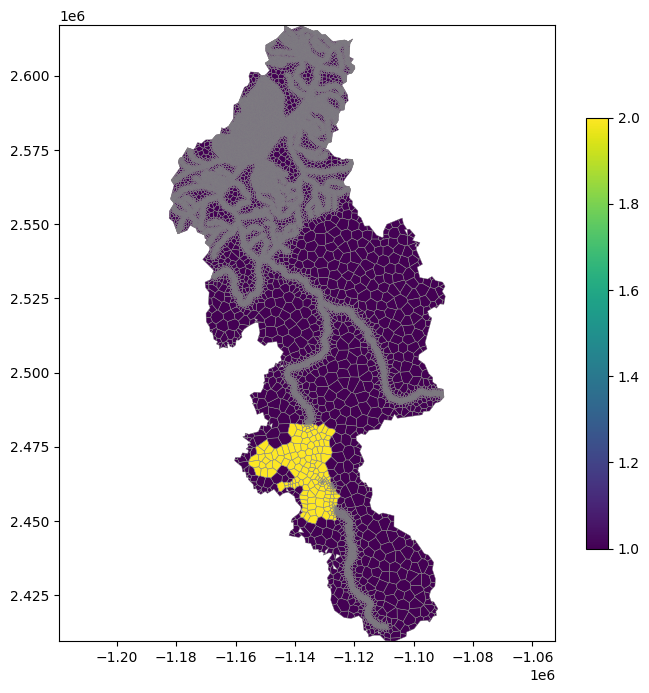

In [ ]:
# plot the difference between the conditioned and filled dem
#diff = strm_msk_dem - filled_dem
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=tg[0], ax=ax)
pc = pmv.plot_array(hru_type)
pmv.plot_grid(lw=0.3)
plt.colorbar(pc, shrink=0.7)
#geom.plot(ax=ax)

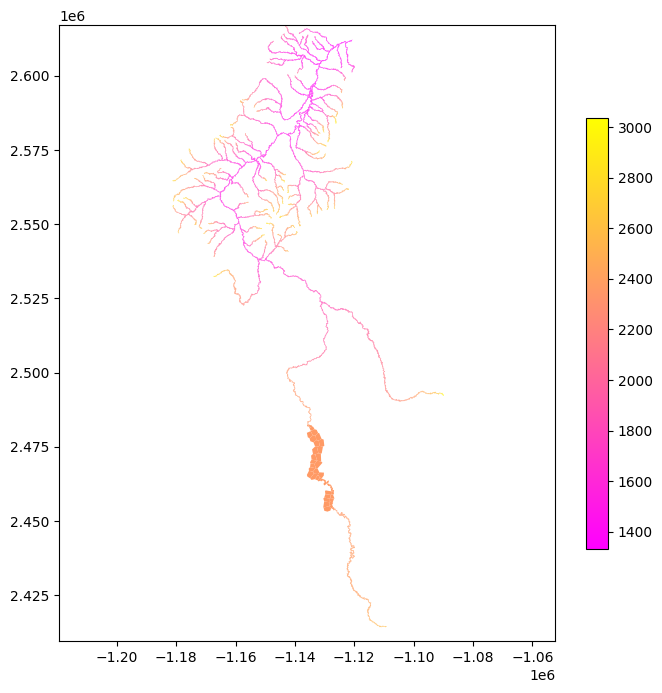

In [158]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=tg[0], ax=ax)
pc = pmv.plot_array(strm_dem, masked_values=[np.nan], cmap='spring')
#pmv.plot_grid(lw=0.3)
plt.colorbar(pc, shrink=0.7)

In [18]:
conditioned_dem = dany.fill_sinks(tg[0], conditioned_dem)

In [21]:
conditioned_dem[1896] = 1334.0

In [22]:
fdobj = dany.FlowDirections(tg[0], conditioned_dem)
fdir_arr = fdobj.flow_directions()
facc_arr = fdobj.flow_accumulation()

running dijkstra


In [28]:
snks = find_undeclared_sinks(fdobj.flow_direction_array)

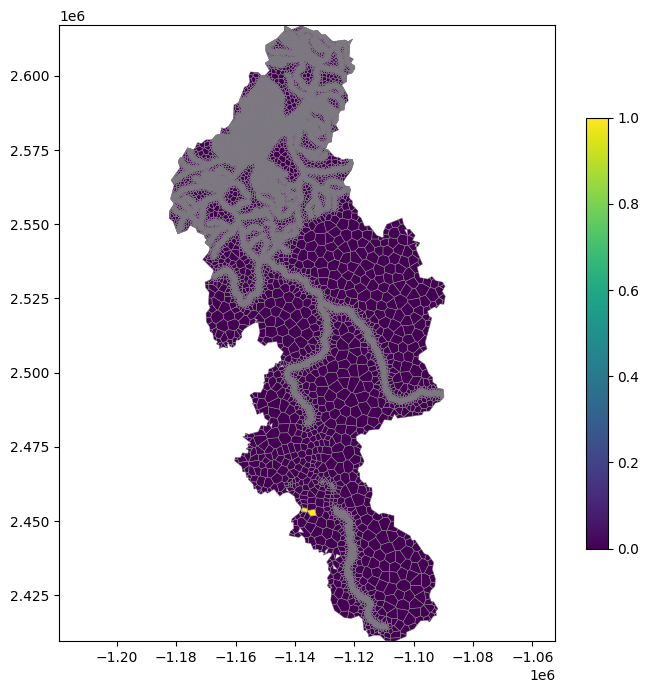

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=tg[0], ax=ax)
pc = pmv.plot_array(snks)
pmv.plot_grid(lw=0.3)
plt.colorbar(pc, shrink=0.7)

In [82]:
fd = fdobj.flow_direction_array

In [83]:
np.where(fd == 0)

(array([    1, 45267]),)

In [20]:
# output diagnostics grid
outgrd = grd_gdf.copy()
outgrd['elevation'] = dem
outgrd['fill_elevation'] = conditioned_dem
outgrd['fill_dem_diff'] = conditioned_dem - filled_dem
outgrd['flow_directions'] = fdobj.flow_direction_array
outgrd['flow_accum'] = fdobj.flow_accumulation_array

In [21]:
outgrd.to_file(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\flow_directions_grid.shp'))

C:\Users\CNB968\AppData\Local\Temp\ipykernel_2732\642550520.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  outgrd.to_file(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\flow_directions_grid.shp'))


In [22]:
up = grd_gdf.centroid
dwn = grd_gdf.iloc[fdobj.flow_direction_array, :].centroid

In [23]:
from shapely.geometry import LineString
casc_lines = [LineString([p1, p2]) for p1, p2 in zip(up, dwn)]

In [24]:
casgdf = gpd.GeoDataFrame(geometry=casc_lines, crs=5071)

In [25]:
casgdf.to_file(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\cascade_paths.shp'))

In [ ]:
fdobj = dany.FlowDirections(vgrid, conditioned_dem)
fdir_arr = fdobj.flow_directions()
facc_arr = fdobj.flow_accumulation()

outlet_node = np.nanargmin(conditioned_dem)
xc = vgrid.xcellcenters[outlet_node]
yc = vgrid.ycellcenters[outlet_node]
watershed = fdobj.get_watershed_boundary([xc, yc])

qx, qy = fdobj.vectors

In [ ]:
# This class provides methods to build a completely parameterized PRMS parameter file for cascade and terrain information
#   inherits a PRMSParameters object which should have all that classes methods to get pygsflow objects and use them to write to .params text file can use xarray to output netcdf
#   this class also handles assigning subbasins, and creating a stream_array based on NHD segments

# Custom initialization pygsflow PrmsBuilder.build() using a PRMSParameters object:
# Must initialize the following parameters in the PRMSParamters object
#   hru_up_id: use PrmsStreams class PrmsStreams.get_cascades() with a custom stream_array argument
#   hru_down_id: use PrmsStreams class PrmsStreams.get_cascades() with a custom stream_array argument
#   hru_pct_up: use PrmsStreams class PrmsStreams.get_cascades() with a custom stream_array argument
#   hru_slope: set from class method calculate_terrain_paramters() using dany.FlowDirections() object
#   hru_aspect: set from class method calculate_terrain_paramters() using dany.FlowDirections() object
#   hru_area: set from class method calculate_terrain_paramters() using dany.FlowDirections() object
#   hru_strmseg_down_id: use PrmsStreams class PrmsStreams.get_cascades() with a custom stream_array argument
#   cascade_flag: set manually to 1
#   nsegments: count nreaches
#   nreaches: get from nhd grid intersect
#   elev_units: set manually (user input?)
#   hru_elev: set from class method calculate_terrain_paramters()
#   hru_lat: set from class method calculate_terrain_paramters()
#   hru_type: uses default of all 1's (ACTIVE) or accepts user input
#   hru_subbasin: use class method with input of pour points from dany.FlowDirections() object
#   subbasin_down: use class method for this, get from subbasin elevations? or maybe from FlowDirections() object there is a way?

class PRMSCascades(PRMSParameters):

    def __init__(self, 
                 modelgrid: Union[str, Path, PRMSVertexGrid, FlopyVertexGrid, gpd.GeoDataFrame],
                 hru_types: Optional[np.ndarray] = None):
        super().__init__(grid=modelgrid)
        self.fdir = None
        self.streams_grid = None
        if hru_types is None:
            self.add_parameter(
                "hru_type",
                np.ones(self.grid.index.values.shape),
                len(self.grid),
                'nhru'
            )
        else:
            self.add_parameter(
                "hru_type",
                hru_types,
                len(self.grid),
                'nhru'
            )
        self.add_parameter(
            "hru_subbasin",
            np.ones((len(self.grid),), dtype=int),
            len(self.grid),
            'nhru'
        )

    def _get_flow_direct_obj(self, elev: Union[str, Path, rio.DatasetReader, xr.DataArray, xr.Dataset]):

    def cascades_from_hydrography(self, 
                                  elev: Union[str, Path, rio.DatasetReader, xr.DataArray, xr.Dataset],
                                  hydrog: gpd.GeoDataFrame):
    
    def add_subbasins(self, pour_pnts: gpd.GeodataFrame):
        pass

SyntaxError: invalid syntax (3767214173.py, line 8)

In [9]:
meta.is_available('rain')

False

In [6]:
pywat_phru = xr.open_dataset(r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSAtmosphere.nc')

In [8]:
p = PRMSParameters.load_netcdf([r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSAtmosphere.nc',
                                r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSCanopy.nc',
                                r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSChannel.nc'])

In [6]:
p1 = PRMSParameters.load_netcdf(r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSAtmosphere.nc')
p2 = PRMSParameters.load_netcdf(r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSCanopy.nc')

In [17]:
p1._pygsflow_dimrecs

In [18]:
p1.pygsflow_param_obj.write('p1.params')

In [11]:
pcomb = join_pygsflow_params([p1.pygsflow_param_obj, p2.pygsflow_param_obj], separate_files=True)

3524201249.py:312: UserWarning: No filenames were provided, using defaults. Defaults saved to 'c:\Users\CNB968\OneDrive - MT\GitHub\MIHMS'


In [16]:
pcomb.parameter_files

['paramfile_01.params', 'paramfile_00.params']

In [12]:
pcomb.write()

In [9]:
p.parameters

<xarray.Dataset> Size: 1MB
Dimensions:              (ndoy: 366, nhru: 765, nmonth: 12, scalar: 1,
                          nsegment: 456)
Coordinates:
    doy                  (ndoy) int64 3kB ...
    nhm_id               (nhru) int64 6kB 5307 5308 5309 5310 ... 7249 7250 7251
    nhm_seg              (nsegment) int64 4kB ...
Dimensions without coordinates: ndoy, nhru, nmonth, scalar, nsegment
Data variables: (12/35)
    adjmix_rain          (nmonth, nhru) float64 73kB ...
    dday_intcp           (nmonth, nhru) float64 73kB ...
    dday_slope           (nmonth, nhru) float64 73kB ...
    jh_coef              (nmonth, nhru) float64 73kB ...
    jh_coef_hru          (nhru) float64 6kB ...
    ppt_rad_adj          (nmonth, nhru) float64 73kB ...
    ...                   ...
    hru_segment          (nhru) int64 6kB ...
    mann_n               (nsegment) float64 4kB ...
    obsin_segment        (nsegment) int64 4kB ...
    obsout_segment       (nsegment) float64 4kB ...
    segment_flow_init    (nsegment) float64 4kB ...
    x_coef               (nsegment) float64 4kB ...

In [10]:
pygob = p.pygsflow_param_obj

In [11]:
pygob.write('test_params.params')

In [6]:
p = PRMSParameters.load_paramfile([r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\climate_hru.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gis.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gsflow.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gvr.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\map_results.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\ncascade.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\ncascdgw.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\strmflow_in_out.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\subbasin.params'])

------------------------------------
Reading parameter file : climate_hru.params
------------------------------------
------------------------------------
Reading parameter file : gis.params
------------------------------------
------------------------------------
Reading parameter file : gsflow.params
------------------------------------
------------------------------------
Reading parameter file : gvr.params
------------------------------------
------------------------------------
Reading parameter file : map_results.params
------------------------------------
------------------------------------
Reading parameter file : ncascade.params
------------------------------------
------------------------------------
Reading parameter file : ncascdgw.params
------------------------------------
------------------------------------
Reading parameter file : strmflow_in_out.params
------------------------------------
------------------------------------
Reading parameter file : subbasin.params
-

prms_parameter.py:217: UserWarning: Duplicate parameter nrain found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ncascade found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nsegment found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ntemp found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ngw found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ncascdgw found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nreach found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nobs found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nhru found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nssr found, overwriting with new values
prms_parameter.py:217: Us

In [7]:
p.parameters

<xarray.Dataset> Size: 223kB
Dimensions:               (one: 1, nhru: 128, ntemp: 2, nssr: 128, nmonths: 12,
                           ndeplval: 22, nhrucell: 4691, ncascade: 317,
                           ncascdgw: 317, nsegment: 15, nsub: 2)
Dimensions without coordinates: one, nhru, ntemp, nssr, nmonths, ndeplval,
                                nhrucell, ncascade, ncascdgw, nsegment, nsub
Data variables: (12/125)
    snow_cbh_adj          (one) float64 8B 1.0
    rain_cbh_adj          (one) float64 8B 1.0
    tmin_cbh_adj          (one) float64 8B 0.0
    potet_cbh_adj         (one) float64 8B 1.0
    tmax_cbh_adj          (one) float64 8B 0.0
    gwstor_min            (one) float64 8B 0.0
    ...                    ...
    segment_type          (one) int64 8B 1
    obsin_segment         (one) int64 8B 0
    obsout_segment        (one) int64 8B 0
    segment_flow_init     (one) float64 8B 0.0
    subbasin_down         (nsub) int64 16B 2 0
    hru_subbasin          (nhru) int64 1kB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2

In [52]:
print(p.get_record('mxsziter'))


####
mxsziter 10
1
one
1
1
25
####


In [12]:
p = pygsflowparams.load_from_file([r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\climate_hru.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gis.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gsflow.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\gvr.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\map_results.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\ncascade.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\ncascdgw.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\strmflow_in_out.params',
                                   r'C:\Users\CNB968\OneDrive - MT\Modeling\GSFLOW\PRMS\prms_5.2.1\projects\sagehen\input\subbasin.params'])

------------------------------------
Reading parameter file : climate_hru.params
------------------------------------
------------------------------------
Reading parameter file : gis.params
------------------------------------
------------------------------------
Reading parameter file : gsflow.params
------------------------------------
------------------------------------
Reading parameter file : gvr.params
------------------------------------
------------------------------------
Reading parameter file : map_results.params
------------------------------------
------------------------------------
Reading parameter file : ncascade.params
------------------------------------
------------------------------------
Reading parameter file : ncascdgw.params
------------------------------------
------------------------------------
Reading parameter file : strmflow_in_out.params
------------------------------------
------------------------------------
Reading parameter file : subbasin.params
-

prms_parameter.py:217: UserWarning: Duplicate parameter nrain found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ncascade found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nsegment found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ntemp found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ngw found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ncascdgw found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nreach found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nobs found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nhru found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nssr found, overwriting with new values
prms_parameter.py:217: Us

In [17]:
p.parameters_list[0] in p.parameters_list

True

In [21]:
p.pygsflow_param_obj.get_record('jh_coef_hru').dimensions_names

['nhru']

In [146]:
p.parameters

<xarray.Dataset> Size: 1MB
Dimensions:              (ndoy: 366, nhru: 765, nmonth: 12, scalar: 1)
Coordinates:
    doy                  (ndoy) int64 3kB ...
    nhm_id               (nhru) int64 6kB ...
Dimensions without coordinates: ndoy, nhru, nmonth, scalar
Data variables: (12/22)
    adjmix_rain          (nmonth, nhru) float64 73kB 1.0 1.0 ... 0.7888 1.304
    dday_intcp           (nmonth, nhru) float64 73kB -10.0 -10.0 ... -11.0 -11.0
    dday_slope           (nmonth, nhru) float64 73kB 0.2962 0.2942 ... 0.4503
    jh_coef              (nmonth, nhru) float64 73kB 0.005448 ... 0.004153
    jh_coef_hru          (nhru) float64 6kB -5.8 -5.8 -5.8 ... -21.98 -23.75
    ppt_rad_adj          (nmonth, nhru) float64 73kB 0.02 0.02 ... 0.02 0.02
    ...                   ...
    tmax_cbh_adj         (nmonth, nhru) float64 73kB 1.182 1.343 ... 1.764 3.0
    tmax_index           (nmonth, nhru) float64 73kB 50.0 50.0 ... 50.0 50.0
    tmin_cbh_adj         (nmonth, nhru) float64 73kB 1.591 1.438 ... 0.8867
    transp_beg           (nhru) int64 6kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    transp_end           (nhru) int64 6kB 13 13 13 13 13 13 ... 13 13 13 13 13
    transp_tmax          (nhru) float64 6kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

In [24]:
rec = p.pygsflow_param_obj

In [157]:
rec.get_record('jh_coef_hru').dims

[765]

In [170]:
test1 = PRMSParameters.load_pygsflow_obj(rec)

In [179]:
test1.parameters.dims

FrozenMappingWarningOnValuesAccess({'nmonth': 12, 'nhru': 765, 'scalar': 1})

In [175]:
rec.parameters_list[0].section

'Parameters'

In [172]:
rec.write('test_params.param')

In [174]:
test2 = PRMSParameters.load_paramfile('test_params.param')

------------------------------------
Reading parameter file : test_params.param
------------------------------------


KeyError: 'nhru'

In [25]:
recdic = rec.get_record('jh_coef_hru')

In [116]:
rec.get_record('adjmix_rain').dimensions_names[1] not in list(meta.dimensions.keys())

False

In [168]:
recdic.dimensions_names

['nhru']

In [26]:
nwparam = PRMSParameters()

In [28]:
nwparam.add_parameter(recdic.name,
                      recdic.values,
                      recdic.dims,
                      recdic.dimensions_names,
                      attributes={'a_test': 'what_up_att-UR-bute'},
                      arr_format='F')

In [29]:
nwparam.parameters

<xarray.Dataset> Size: 6kB
Dimensions:      (nhru: 765)
Dimensions without coordinates: nhru
Data variables:
    jh_coef_hru  (nhru) float64 6kB -5.8 -5.8 -5.8 ... -21.78 -21.98 -23.75

In [86]:
rec.write('test_params')

In [7]:
import xarray as xr
import numpy as np

t = xr.Dataset()
t['SomeNumbers'] = (('n'), np.array([1,2,3,4,5]), {'units': 'something for sure'})
t['SomeLetters'] = (('m'), ['a','b','c','d'], {'units': 'these are just letters?'})

In [9]:
tup = (1,2,3)

In [11]:
for i in tup:
    print(i)

1
2
3


In [28]:
tI = flopy.utils.GridIntersect(tg[0], method='vertex')

In [51]:
prms_cell_type = np.ones(tg[0].xcellcenters.shape[0])

In [ ]:
li = tI.intersect(lakes, geo_dataframe=True, contains_centroid=True)
prms_cell_type[li['cellids'].values.astype(int)] = 2

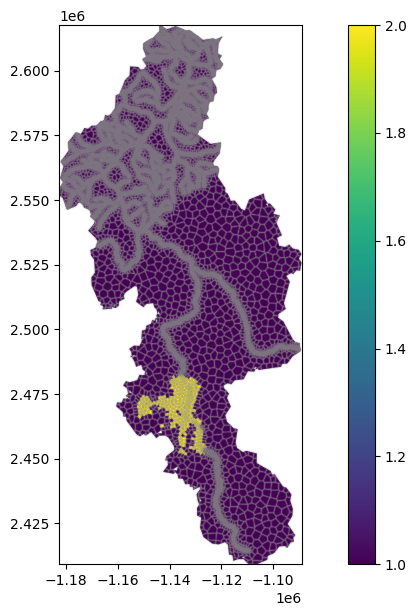

In [53]:
fig, ax = plt.subplots(figsize=(12, 7))
pmv = flopy.plot.PlotMapView(modelgrid=tg[0]) 
pc = pmv.plot_array(prms_cell_type)
pmv.plot_grid(alpha=0.2)
plt.colorbar(pc)

In [48]:
li['cellids'].values.astype(int)

array([  293,   294,   295,   296,   297,   298,   299,   300,   301,
         302,   303,   304,   305,   306,   307,   308,   309,   310,
         311,   312,   313,   314,   315,   316,   317,   318,   319,
         320,   321,   322,   323,   324,   325,   326,   327,   328,
         329,   330,   331,   332,   333,   334,   335,   336,   337,
         338,   339,  2569,  2570,  2571,  2572,  2573,  2574,  2575,
        2576,  2577,  2578,  2579,  2580,  2581,  2582,  2583,  2752,
        2753,  2754,  2755,  2756,  2757,  2758,  2759,  2760,  2761,
        2762,  2763,  2764,  2765,  2766,  3127,  3128,  3129,  3130,
        3183,  3184,  3185,  3186,  3187,  3188,  3189,  3190,  3191,
        3192,  3193,  3194,  3427,  3428,  3429,  3430,  3439,  3440,
        3441,  3442,  3443,  3527,  3528,  3531,  3532,  3533,  3660,
        3663,  3664,  3665,  3666,  3667,  3671,  3672,  3673,  3674,
        3675,  3713,  3714,  3715,  3716,  3719,  3758,  3762,  3763,
        3764,  3765,

In [ ]:
grd_gdf = tg[0].geo_dataframe
grd_gdf = grd_gdf.set_crs(5071)

In [47]:
grd_gdf = grd_gdf.set_crs(5071)

In [ ]:
grd_elev = gt.calc_zonal_stats(grd_gdf, clp_elev_pth, stats='min', all_touched=True)
dem = np.where(grd_elev.values.ravel() == rstr.nodatavals[0], np.nan, grd_elev.values.ravel())

C:\Users\CNB968\AppData\Local\Temp\ipykernel_13856\3234759935.py:1: UserWarning: Not all geometries were returned, 3 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  grd_elev = gt.calc_zonal_stats(grd_gdf, clp_elev_pth, stats='min', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


In [49]:
grd_elev

,,,Value
FID,Band,stat,
0,1,min,2393
1,1,min,2379
2,1,min,2308
3,1,min,2268
4,1,min,2382
...,...,...,...
88340,1,min,2477
88341,1,min,2012
88342,1,min,2008


Convert vector geometry data into single polygons

In [18]:
# Specify approximate grid resolution for refinement areas
strm_res = 100 # in meters
# this should scale by size of basin
base_res = 2500 # 2.5 km
# this should be some fraction scaled by the size of the lake
lake_res = 1000 # 1 km

<Axes: >

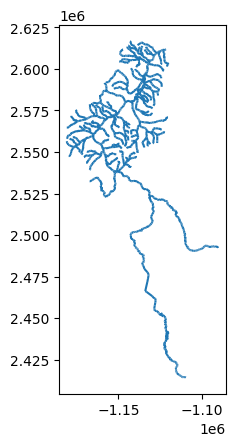

In [19]:
simp_strms = gpd.GeoDataFrame(
    geometry = streams.geometry.simplify(strm_res)
)
simp_strms.plot()

<Axes: >

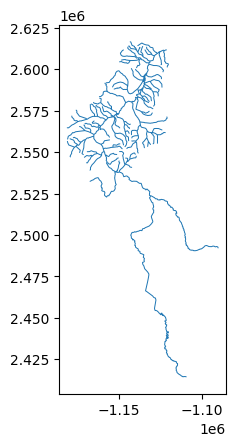

In [12]:
buff_strms = simp_strms.dissolve()
buff_strms['geometry'] = buff_strms.geometry.buffer(strm_res*3, cap_style='round',resolution=8, join_style='round')
buff_strms.plot()

In [72]:
buff_strms.to_file(clp_elev_pth.parent / 'strms.shp')

<Axes: >

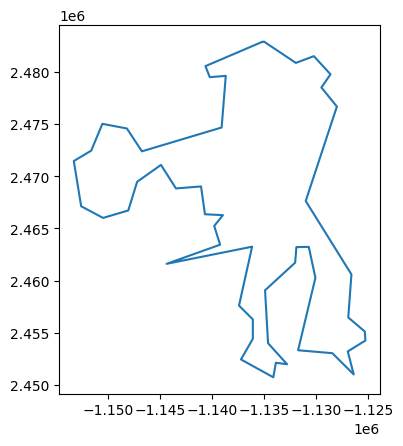

In [27]:
lakes.exterior.simplify(700).plot()

Simplify the geometries to reduce the number of nodes passed to Triangle.

In [13]:
strm_reg = buff_strms.geometry.simplify(strm_res)
#strm_reg = buff_strms
basin_reg = basin.geometry.simplify(base_res/5)
lake_reg = lakes.exterior.simplify(700)
lake_reg = lake_reg.polygonize().force_2d()

In [14]:
if not strm_reg.within(basin_reg).all():
    strm_reg = strm_reg.clip(basin_reg)
    basin_reg = basin_reg.geometry.buffer(strm_res*3, join_style='mitre')

In [15]:
regs = [strm_reg, basin_reg, lake_reg]
reg_nm = ['strms', 'bsn', 'lake']
for i in range(len(regs)):
    F = gpd.GeoDataFrame(geometry=regs[i])
    F.to_file(clp_elev_pth.parent / f'{reg_nm[i]}.shp')

Next, we find the differences of all input polygons (basin, streams, lakes) and sample a single point within each difference polygon so that these regions can be passed to triangle.

<Axes: >

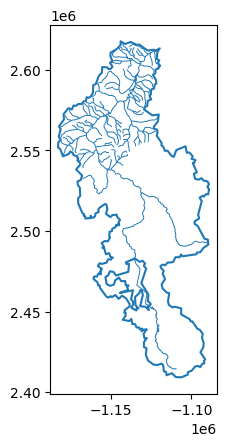

In [15]:
ax = basin_reg.boundary.plot()
strm_reg.plot(ax=ax)
lake_reg.boundary.plot(ax=ax)


<Axes: >

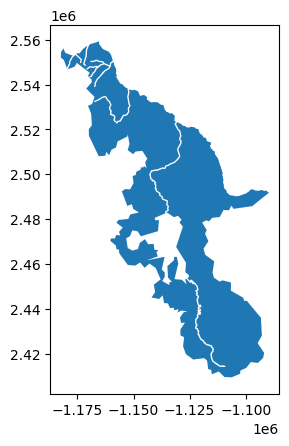

In [77]:
bsn_dif = basin_reg.difference(strm_reg.geometry[0]).explode().reset_index().drop(columns='index')
bsn_dif = bsn_dif.difference(lake_reg.geometry[0]).explode().reset_index().drop(columns='index')
bsn_dif.loc[[9],:].plot()

In [16]:
bsn_dif = basin_reg.difference(strm_reg.geometry[0]).explode().reset_index().drop(columns='index')
bsn_dif = bsn_dif.difference(lake_reg.geometry[0]).explode().reset_index().drop(columns='index')
bsn_dif = gpd.GeoDataFrame({'region': ['basin'] * len(bsn_dif)}, geometry=bsn_dif.geometry, index=range(0, len(bsn_dif)))
strm_dif = strm_reg.difference(lake_reg.geometry[0]).explode().reset_index().drop(columns='index')
strm_dif = gpd.GeoDataFrame({'region': ['stream'] * len(strm_dif)}, geometry=strm_dif.geometry)
lake_dif = lake_reg.difference(strm_reg.geometry[0]).explode().reset_index()
lake_dif = gpd.GeoDataFrame({'region': ['lake'] * len(lake_dif)}, geometry=lake_dif.geometry)

diff_polys = pd.concat([bsn_dif, strm_dif, lake_dif], ignore_index=True)


In [17]:
diff_pnts = diff_polys.copy()
diff_pnts['geometry'] = diff_polys.sample_points(1)

In [19]:
diff_pnts

,region,geometry
0,basin,POINT (-1132842.178 2520724.057)
1,basin,POINT (-1120591.446 2437979.382)
2,basin,POINT (-1137122.7 2584406.999)
3,basin,POINT (-1137162.652 2586468.133)
4,basin,POINT (-1131575.698 2588772.67)
5,basin,POINT (-1134608.903 2593154.33)
6,stream,POINT (-1164928.439 2577736.257)
7,stream,POINT (-1121039.062 2430435.22)
8,lake,POINT (-1131625.721 2474637.693)
9,lake,POINT (-1134216.895 2464434.073)


In [147]:
diff_polys.to_file(clp_elev_pth.parent / 'triangle_region_points.shp')

<Axes: >

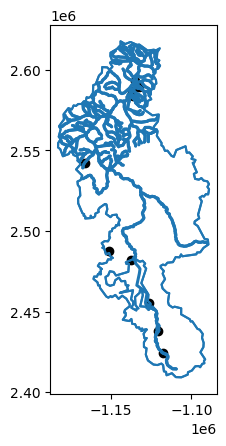

In [18]:
ax = basin_reg.boundary.plot()
diff_polys.boundary.plot(ax=ax)
diff_pnts.plot(ax=ax, marker='o', color='black')

Create Triangle instance and working directory.

In [19]:
tri_pth = Path('./example/Yellowstone/tri_wd')
#tri_pth = Path('C:/Users/CNB968/OneDrive - MT/GitHub/MIHMS/example/Yellowstone/tri_wd')
tri_pth.mkdir(exist_ok=True)
tri_grid = Triangle(exe_name=tri_exe, angle=20, model_ws=tri_pth)

Add the polygons and all regions formed by the differences/intersections of the polygons with their assigned max_areas.

In [ ]:
tri_grid.add_polygon(basin_reg[0], ignore_holes=True)
tri_grid.add_polygon(lake_reg[0], ignore_holes=True)
#tri_grid.add_polygon(strm_reg[0], ignore_holes=True)

tri_grid.add_region(basin.centroid.values[0], maximum_area=base_res**2)
tri_grid.add_region(lakes.centroid.values[0], maximum_area=lake_res**2)
#tri_grid.add_region(streams.geometry.values[0].centroid, maximum_area=strm_res**2)
tri_grid.build()

CalledProcessError: Command '['C:\\Users\\CNB968\\OneDrive - MT\\GitHub\\MIHMS\\triangle\\triangle.exe', '-a', '-q20', '-A', '-p', '-V', '-D', '-e', '-n', '_triangle.0']' returned non-zero exit status 1.

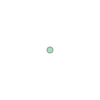

In [152]:
lake_reg.sample_points(1).iloc[0]

In [20]:
#tri_grid.add_polygon(strm_reg[0], ignore_holes=True)
tri_grid.add_polygon(basin_reg[0], ignore_holes=True)
tri_grid.add_polygon(lake_reg[0], ignore_holes=True)
tri_grid.add_polygon(strm_reg[0], ignore_holes=True)

#tri_grid.add_region(diff_pnts.geometry[0], maximum_area=base_res**2)
#tri_grid.add_region(diff_pnts.geometry[1], maximum_area=base_res**2)
#tri_grid.add_region(lake_reg.sample_points(1)[0], maximum_area=lake_res**2)
#tri_grid.add_region(diff_pnts.geometry[7], maximum_area=strm_res**2)
#tri_grid.add_region(diff_pnts.geometry[8], maximum_area=strm_res**2)

In [21]:
reg_resltns = {
    'basin': base_res,
    'stream': strm_res,
    'lake': lake_res
}
for i in range(len(diff_pnts)):
    desg = diff_pnts.loc[i, 'region']
    tri_grid.add_region(diff_pnts.geometry[i], maximum_area=reg_resltns[desg]**2)

In [ ]:
reg_resltns = {
    'basin': base_res,
    'stream': strm_res,
    'lake': lake_res
}
for i in range(len(diff_polys)):
    desg = diff_polys.loc[i, 'region']
    tri_grid.add_polygon(diff_polys.geometry[i], ignore_holes=True)
    tri_grid.add_region(diff_pnts.geometry[i], maximum_area=reg_resltns[desg]**2)

In [22]:
tri_grid.build()

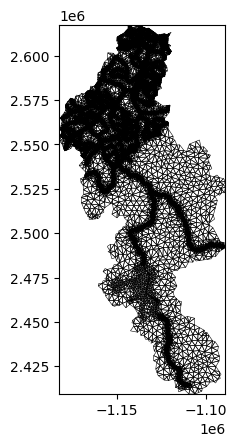

In [23]:
tri_grid.plot(lw=0.4)

In [24]:

vor = VoronoiGrid(tri_grid)
gridprops = vor.get_gridprops_vertexgrid()
vgrid = flopy.discretization.VertexGrid(nlay=1, **gridprops)

In [25]:
grd_gdf = vgrid.geo_dataframe
grd_gdf = grd_gdf.set_crs(5071)

<Axes: >

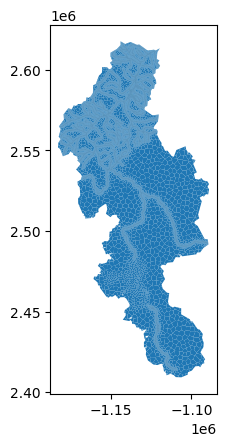

In [26]:
grd_gdf.plot()

In [28]:
grd_gdf.to_file(clp_elev_pth.parent / 'UY_Voronoi_Grid.shp')

In [26]:
grd_elev = gt.calc_zonal_stats(grd_gdf, clp_elev_pth, stats='min', all_touched=True)

C:\Users\CNB968\AppData\Local\Temp\ipykernel_15676\3234759935.py:1: UserWarning: Not all geometries were returned, 1 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  grd_elev = gt.calc_zonal_stats(grd_gdf, clp_elev_pth, stats='min', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


In [27]:
dem = np.where(grd_elev.values.ravel() == rstr.nodatavals[0], np.nan, grd_elev.values.ravel())

In [28]:
def fill_voronoi_nan(array, grid):
    in_array = array.copy()
    
    nanidx = np.where(np.isnan(in_array))[0]
    n_nans = len(nanidx)

    if n_nans != 0:
        print(f"Filling {n_nans} missing grid cell values...")
        iter = 0
        while iter < 10:
            nanidx = np.where(np.isnan(in_array))[0]
            n_nans = len(nanidx)
            
            if n_nans == 0:
                break
            
            for idx in nanidx:
                cell_adj = grid.loc[grid.intersects(grid.loc[idx, 'geometry']),:].index
                in_array[idx] = np.nanmean(in_array[cell_adj])
            
            iter += 1

    else:
        print("Input array has no missing values.")

    return in_array

In [37]:
test = flopy.utils.GridIntersect(vgrid, method='vertex')

In [41]:
s_intx = []
for geom in streams.geometry.values:
    cellids = test.intersect(geom)['cellids']
    s_intx.extend(list(cellids))

strm_mask = np.zeros((vgrid.ncpl,), dtype=int)
strm_mask[s_intx] = 1

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
test.intersect()

In [29]:
filled_dem = fill_voronoi_nan(dem, grd_gdf)
conditioned_dem = dany.fill_sinks(vgrid, filled_dem)

Filling 78 missing grid cell values...


In [44]:
# with stream network conditioning
strm_msk_dem = dany.fill_sinks(vgrid, filled_dem, eps=2e-06, stream_mask=strm_mask)

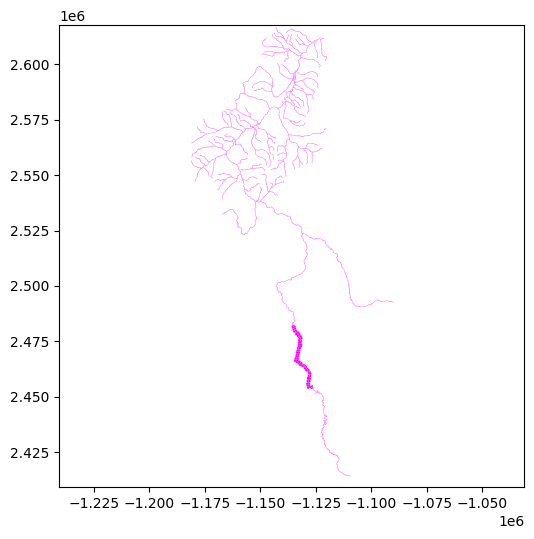

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=vgrid, ax=ax)
pc = pmv.plot_array(strm_mask, masked_values=[0,], cmap="spring")

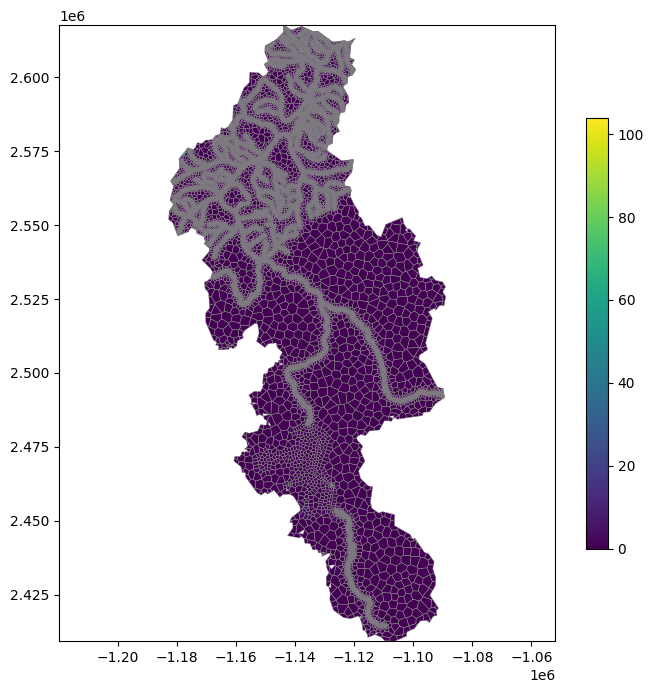

In [45]:
# plot the difference between the conditioned and filled dem
diff = strm_msk_dem - filled_dem
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=vgrid, ax=ax)
pc = pmv.plot_array(diff)
pmv.plot_grid(lw=0.3)
plt.colorbar(pc, shrink=0.7)

In [47]:
fdobj = dany.FlowDirections(vgrid, conditioned_dem)
fdir_arr = fdobj.flow_directions()
facc_arr = fdobj.flow_accumulation()

running dijkstra
running dijkstra
running dijkstra
running dijkstra
running dijkstra
running dijkstra
running dijkstra


In [48]:
outlet_node = np.nanargmin(conditioned_dem)
xc = vgrid.xcellcenters[outlet_node]
yc = vgrid.ycellcenters[outlet_node]
watershed = fdobj.get_watershed_boundary([xc, yc])

qx, qy = fdobj.vectors

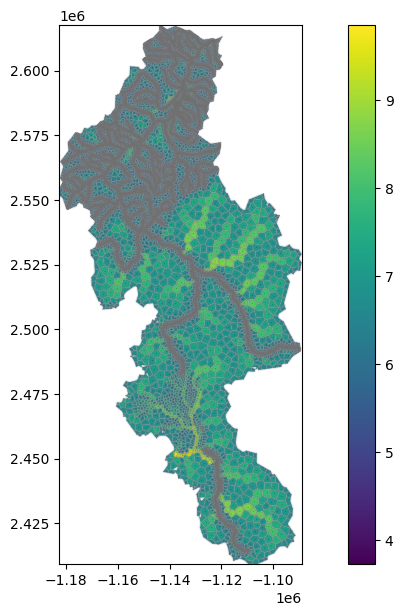

In [49]:
fig, ax = plt.subplots(figsize=(12, 7))
pmv = flopy.plot.PlotMapView(modelgrid=vgrid) 
pc = pmv.plot_array(np.log10(facc_arr))
pmv.plot_vector(qx, qy)
pmv.plot_grid(alpha=0.2)
plt.colorbar(pc)

In [50]:
prms_streams = dany.PrmsStreams(vgrid, fdobj)

In [51]:
pgsf_casc = prms_streams.get_pygsflow_builder_object(stream_array=strm_mask, group_segments=False, many2many=False)

In [52]:
pgsf_casc.__dict__

{'dany_flag': True,
 'ncascade': 176866,
 'hru_up_id': array([    1,     2,     1, ..., 87151, 87160, 87510]),
 'hru_down_id': array([86803, 86803, 86803, ..., 87267, 87267, 87267]),
 'hru_pct_up': array([1., 1., 1., ..., 1., 1., 1.]),
 'hru_strmseg_down_id': array([0, 0, 0, ..., 0, 0, 0]),
 'cascade_flag': 1,
 'hru_slope': array([0.05838274, 0.05158475, 0.00490245, ..., 0.02781382, 0.08744165,
        0.08998895]),
 'hru_aspect': array([ 86.19892423,  64.99166899,  93.14969064, ...,  14.00943852,
        250.08240366, 287.85650819]),
 'hru_area': array([3935875.48803711, 4885228.74389648, 4709076.18994141, ...,
        7085094.46533203, 6930133.69189453, 7473229.08154297]),
 'nsegments': 15403,
 'nreaches': 15403}

In [63]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

In [65]:
with open('UY_voronoi_grid.json', 'w') as f:
    json.dump(gridprops, f, cls=NpEncoder)

In [67]:
with open('UY_voronoi_grid.json') as f:
    grid = json.load(f)

In [69]:
loaded_grid = flopy.discretization.VertexGrid(nlay=1, **grid)

In [70]:
loaded_grid.xyzcellcenters

[array([-1152640.63820969, -1153532.04517736, -1156887.02054019, ...,
        -1126280.98449418, -1103039.64554407, -1099764.24707825]),
 array([2516534.20894073, 2516763.16135029, 2514435.90315372, ...,
        2491228.72389083, 2529525.29679194, 2530405.87564958]),
 array(None, dtype=object)]

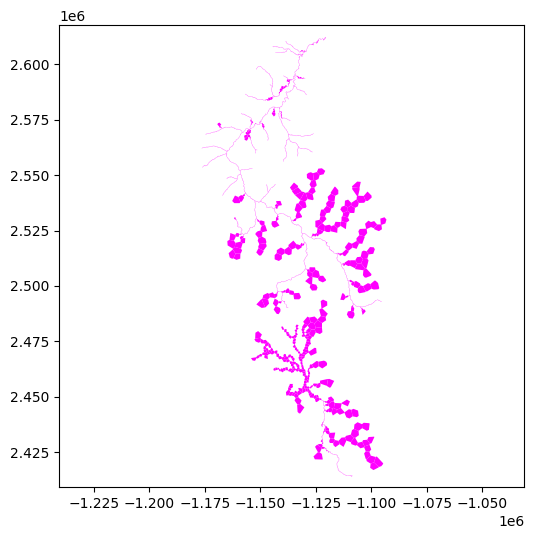

In [35]:
contrib_area = 3e7  # m^2
stream_array = prms_streams.delineate_streams(contrib_area)

# plot the flow directions and flow accumulation array
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=vgrid, ax=ax)
pc = pmv.plot_array(stream_array, masked_values=[0], cmap="spring")
#pmv.plot_vector(qx, qy)
#pmv.plot_grid(color="k", lw=0.2)

In [38]:
pgsf_casc = prms_streams.get_pygsflow_builder_object(group_segments=False, many2many=False)

In [39]:
pgsf_casc.__dict__

{'dany_flag': True,
 'ncascade': 176866,
 'hru_up_id': array([    1,     2,     1, ..., 87151, 87160, 87510]),
 'hru_down_id': array([86803, 86803, 86803, ..., 87267, 87267, 87267]),
 'hru_pct_up': array([1., 1., 1., ..., 1., 1., 1.]),
 'hru_strmseg_down_id': array([ 0,  0,  0, ..., 45, 45, 45]),
 'cascade_flag': 1,
 'hru_slope': array([0.05838274, 0.05158475, 0.00490245, ..., 0.02781382, 0.08744165,
        0.08998895]),
 'hru_aspect': array([ 86.19892423,  64.99166899,  93.14969064, ...,  14.00943852,
        250.08240366, 287.85650819]),
 'hru_area': array([3935875.48803711, 4885228.74389648, 4709076.18994141, ...,
        7085094.46533203, 6930133.69189453, 7473229.08154297]),
 'nsegments': 3840,
 'nreaches': 3840}

In [ ]:
grd_gdf.to_file(clp_elev_pth.parent / 'UY_Voronoi_Grid.shp')

In [104]:
outlet_node = np.nanargmin(conditioned_dem)
xc = vgrid.xcellcenters[outlet_node]
yc = vgrid.ycellcenters[outlet_node]
watershed = fdobj.get_watershed_boundary([xc, yc])

qx, qy = fdobj.vectors

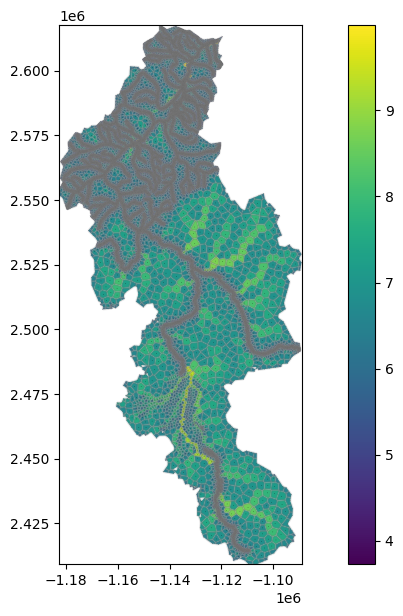

In [105]:
fig, ax = plt.subplots(figsize=(12, 7))
pmv = flopy.plot.PlotMapView(modelgrid=vgrid) 
pc = pmv.plot_array(np.log10(facc_arr))
pmv.plot_vector(qx, qy)
pmv.plot_grid(alpha=0.2)
plt.colorbar(pc)

In [72]:
grd_gdf.loc[grd_gdf.intersects(grd_gdf.loc[202, 'geometry']),:].index

Index([202, 203, 86718], dtype='int64')

In [60]:
grd_gdf.loc[grd_gdf.intersects(grd_gdf.geometry[73]), 'elevation'].mean()

np.float64(2307.5)

In [16]:
import xarray as xr

pywat_phru = xr.open_dataset(r'C:\Users\CNB968\OneDrive - MT\GitHub\pywatershed\test_data\drb_2yr\parameters_PRMSAtmosphere.nc')

In [19]:
p = PRMSParameters(pywat_phru)

In [20]:
p.get_pygsflow_param_obj

ValueError: The input dtype could not be resolved to a prms dtype code.

In [21]:
pywat_phru.dtypes

Frozen({'adjmix_rain': dtype('float64'), 'dday_intcp': dtype('float64'), 'dday_slope': dtype('float64'), 'jh_coef': dtype('float64'), 'jh_coef_hru': dtype('float64'), 'ppt_rad_adj': dtype('float64'), 'radadj_intcp': dtype('float64'), 'radadj_slope': dtype('float64'), 'radj_sppt': dtype('float64'), 'radj_wppt': dtype('float64'), 'radmax': dtype('float64'), 'rain_cbh_adj': dtype('float64'), 'snow_cbh_adj': dtype('float64'), 'temp_units': dtype('int64'), 'tmax_allrain_offset': dtype('float64'), 'tmax_allsnow': dtype('float64'), 'tmax_cbh_adj': dtype('float64'), 'tmax_index': dtype('float64'), 'tmin_cbh_adj': dtype('float64'), 'transp_beg': dtype('int64'), 'transp_end': dtype('int64'), 'transp_tmax': dtype('float64')})

In [8]:
pywat_phru.sizes

Frozen({'ndoy': 366, 'nhru': 765, 'nmonth': 12, 'scalar': 1})

In [47]:
grd_gdf['elevation'] = dem

<Axes: >

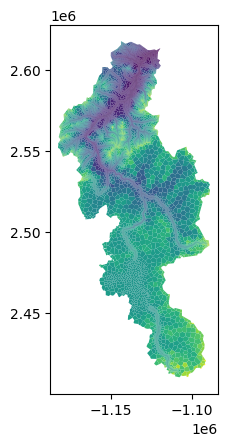

In [48]:
grd_gdf.plot(column='elevation')

In [35]:
import xvec
import rioxarray
import xarray as xr

ds = rioxarray.open_rasterio(clp_elev_pth)

In [28]:
ds = ds.sel(band=1)

In [36]:
ds

<xarray.DataArray (band: 1, y: 6923, x: 3102)> Size: 43MB
[21475146 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 25kB -1.182e+06 -1.182e+06 ... -1.089e+06
  * y            (y) float64 55kB 2.617e+06 2.617e+06 ... 2.41e+06 2.409e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Elevation
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [40]:
grd_gdf = grd_gdf.set_crs(5071)

In [41]:
ds.xvec.zonal_stats(grd_gdf.geometry, x_coords='x', y_coords='y', stats="mean", method='exactextract')

<xarray.DataArray (geometry: 167222, band: 1)> Size: 1MB
array([[1809.23837374],
       [1485.75215359],
       [1436.46365508],
       ...,
       [2360.05502163],
       [2375.76305222],
       [2360.        ]])
Coordinates:
  * geometry  (geometry) object 1MB POLYGON ((-1138158.4681242872 2616735.220...
  * band      (band) int64 8B 1
Indexes:
    geometry  GeometryIndex (crs=EPSG:5071)
Attributes:
    DataType:            Elevation
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [92]:
grd_gdf["id"] = grd_gdf.index + 1

<Axes: >

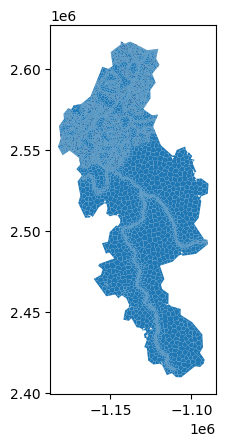

In [56]:
grd_gdf.plot()

In [125]:
grd_gdf.shape

(167222, 2)

<Axes: >

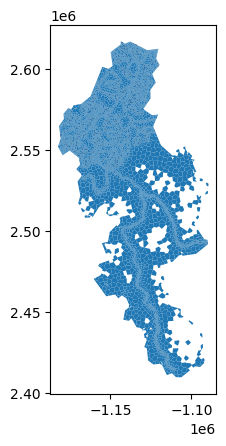

In [133]:
grd_gdf.geometry[0:167000].plot()

In [142]:
geom_value = ((geom,value) for geom, value in zip(grd_gdf.geometry, grd_gdf['id']))

In [143]:
with rio.open(clp_elev_pth) as src:
    rasterized = rio.features.rasterize(
        geom_value,
        out_shape=src.shape,
        fill=0,
        transform=src.transform,
        all_touched=True,
        dtype=np.int64,
        merge_alg=rio.enums.MergeAlg.replace
    )
    dem = src.read(1)

In [103]:
with rio.open(clp_elev_pth) as src:
    ds = src


In [105]:
isinstance(ds, rio.DatasetReader)

True

Affine(-124.7666666333333, 0.041666666666666, 0.0,
       0.0, 0.0, 49.4)

In [79]:
import xarray as xr
ds = xr.open_dataset(r'D:\Spatial_Data\Statewide_Data\Raster\GridMET\Precip\pr_2016.nc')


(366, 585, 1386)

In [98]:
from affine import Affine
gt = ds.crs.GeoTransform.split(' ')
aff = Affine.from_gdal(float(gt[0]), float(gt[1]), float(gt[2]), float(gt[4]), 0.0, float(gt[5]))
ds = ds.rio.write_transform(aff)
ds=ds.rio.write_crs(ds.rio.crs)


In [102]:
isinstance(ds, (xr.DataArray, xr.Dataset))

True

In [144]:
len(np.unique(rasterized))

85684

In [145]:
np.unique(rasterized)

array([     0,      1,      2, ..., 167220, 167221, 167222])

In [135]:
np.where(rasterized == 167000)[0].size

5053

In [146]:
b = []
for i in grd_gdf['id'].values:
    cells = np.where(rasterized == i)[0].size
    b.append(cells)

KeyboardInterrupt: 

In [140]:
n = []
for i in grd_gdf['id'].values:
    n.append(i)

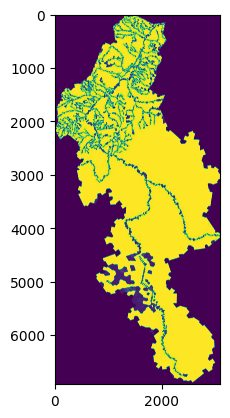

In [118]:
plt.imshow(rasterized)

In [74]:
import pandas as pd

f = pd.DataFrame({'ID': rasterized.ravel(), 'Value': dem.ravel()})
df = f[f.ID != 0]
gdf = df.groupby('ID').agg({'Value': ['mean']})

In [77]:
len(np.unique(rasterized))

85683